# TRANSFER LEARNING FOR COMPUTER VISION PROJECT

## Импорт необходимых библиотек и зависимостей

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import numpy.typing as npt
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import shutil
from PIL import Image
from tempfile import TemporaryDirectory
from typing import Dict, List, Optional, Tuple, Any
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve, precision_recall_curve, matthews_corrcoef
from torchmetrics import Accuracy, Precision, Recall, F1Score, MatthewsCorrCoef, AUROC, AveragePrecision
import seaborn as sns
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка необходимых данных

### Деархивация архива для примера

In [ ]:
shutil.unpack_archive('./../data/hymenoptera_data/hymenoptera_data.zip', 'hymenoptera_data', 'zip')

### Получение данных для работы

### Music_dataset

In [2]:
device: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# Добавляем test в трансформации
data_transforms: Dict[str, transforms.Compose] = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),  # Добавим аугментацию
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Для устойчивости
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Загрузка датасета
data_dir: str = './../data/music_dataset'
image_datasets: Dict[str, datasets.ImageFolder] = {
    x: datasets.ImageFolder(
        os.path.join(data_dir, x),
        data_transforms[x]
    )
    for x in ['train', 'val', 'test']
}

dataloaders: Dict[str, torch.utils.data.DataLoader] = {
    x: torch.utils.data.DataLoader(
        image_datasets[x], 
        batch_size=4,
        shuffle=True if x == 'train' else False, 
        num_workers=4
    )
    for x in ['train', 'val', 'test']
}

dataset_sizes: Dict[str, int] = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names: List[str] = image_datasets['train'].classes
num_classes: int = len(class_names)
print(f"Классы: {class_names}")
print(f"Размеры датасета: {dataset_sizes}")

Классы: ['drums', 'electro_guitars', 'royale', 'saxophone', 'violin']
Размеры датасета: {'train': 325, 'val': 75, 'test': 101}


## Визуализация изображений из датасета

### Функция для отображений изображений датасета

In [4]:
def imshow(
    inp: torch.Tensor, 
    title: str = None
) -> None:
    """Display image for Tensor."""
    inp: np.ndarray = inp.numpy().transpose((1, 2, 0))
    mean: np.ndarray = np.array([0.485, 0.456, 0.406])
    std: np.ndarray = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

### Оригинальный Music датасет

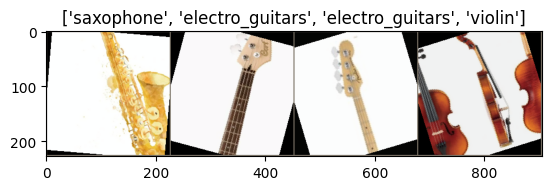

In [5]:
inputs: torch.Tensor
classes: torch.Tensor
inputs, classes = next(iter(dataloaders['train']))
out: torch.Tensor = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

## Функции для построения матрицы возмущений и визуализации тренировочных метрик

In [6]:
def plot_confusion_matrix(
    labels: List[int], 
    preds: List[int], 
    class_names: List[str]
) -> None:
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=class_names, 
        yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_training_metrics_new(
    metrics: Dict[str, List[float]], 
    learning_rates: List[float], 
    val_metrics: Dict[str, List[float]], 
    plot_roc_pr: bool = True
) -> None:
    epochs = range(len(metrics['train_loss']))

    # Convert metrics to numpy arrays for plotting
    train_loss: npt.NDArray[np.float64] = np.array(metrics['train_loss'])
    val_loss: npt.NDArray[np.float64] = np.array(metrics['val_loss'])
    train_acc: npt.NDArray[np.float64] = np.array(metrics['train_acc'])
    val_acc: npt.NDArray[np.float64] = np.array(metrics['val_acc'])

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss', color='#1f77b4')
    plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Accuracy', color='#1f77b4')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='#ff7f0e')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot Learning Rate
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, learning_rates, label='Learning Rate', color='#2ca02c')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot additional validation metrics
    if val_metrics and len(epochs) > 0:
        # Sklearn metrics
        plt.figure(figsize=(12, 8))
        
        # Precision, Recall, F1
        plt.subplot(2, 2, 1)
        if val_metrics.get('precision_skl'):
            plt.plot(epochs, val_metrics['precision_skl'], label='Precision', color='#1f77b4')
        if val_metrics.get('recall_skl'):
            plt.plot(epochs, val_metrics['recall_skl'], label='Recall', color='#ff7f0e')
        if val_metrics.get('f1_skl'):
            plt.plot(epochs, val_metrics['f1_skl'], label='F1', color='#2ca02c')
        plt.title('Precision, Recall, and F1 Score (Sklearn)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # MCC и ROC-AUC
        plt.subplot(2, 2, 2)
        if val_metrics.get('mcc_skl'):
            plt.plot(epochs, val_metrics['mcc_skl'], label='MCC', color='#9467bd')
        if val_metrics.get('roc_auc_skl'):
            plt.plot(epochs, val_metrics['roc_auc_skl'], label='ROC-AUC', color='#8c564b')
        if val_metrics.get('pr_auc_skl'):
            plt.plot(epochs, val_metrics['pr_auc_skl'], label='PR-AUC', color='#e377c2')
        plt.title('MCC, ROC-AUC, PR-AUC (Sklearn)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # Torchmetrics - основные метрики
        plt.subplot(2, 2, 3)
        if val_metrics.get('precision_torch'):
            plt.plot(epochs, val_metrics['precision_torch'], label='Precision', color='#1f77b4')
        if val_metrics.get('recall_torch'):
            plt.plot(epochs, val_metrics['recall_torch'], label='Recall', color='#ff7f0e')
        if val_metrics.get('f1_torch'):
            plt.plot(epochs, val_metrics['f1_torch'], label='F1', color='#2ca02c')
        if val_metrics.get('accuracy_torch'):
            plt.plot(epochs, val_metrics['accuracy_torch'], label='Accuracy', color='#ff9896')
        plt.title('Precision, Recall, F1, Accuracy (Torchmetrics)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        # Torchmetrics - дополнительные метрики
        plt.subplot(2, 2, 4)
        if val_metrics.get('mcc_torch'):
            plt.plot(epochs, val_metrics['mcc_torch'], label='MCC', color='#9467bd')
        if val_metrics.get('roc_auc_torch'):
            plt.plot(epochs, val_metrics['roc_auc_torch'], label='ROC-AUC', color='#8c564b')
        if val_metrics.get('pr_auc_torch'):
            plt.plot(epochs, val_metrics['pr_auc_torch'], label='PR-AUC', color='#e377c2')
        plt.title('MCC, ROC-AUC, PR-AUC (Torchmetrics)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

In [7]:
def plot_hyperparameter_comparison(
    results, 
    param_name: str, 
    metric: str = 'val_acc'
):
    plt.figure(figsize=(10, 6))
    
    for param_value, result in results.items():
        epochs = range(len(result['metrics'][metric]))
        plt.plot(epochs, result['metrics'][metric], 
                label=f'{param_name}={param_value}')
    
    plt.title(f'Сравнение {param_name} по метрике {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Финальные значения
    final_values = {k: v['metrics'][metric][-1] for k, v in results.items()}
    plt.figure(figsize=(8, 5))
    plt.bar([str(k) for k in final_values.keys()], final_values.values())
    plt.title(f'Финальные значения {metric} для разных {param_name}')
    plt.xlabel(param_name)
    plt.ylabel(metric)
    plt.show()

## Тренировка модели на файлах из датасета

### Информация о LR-Sheduler

* class torch.optim.lr_scheduler.LRScheduler(optimizer, last_epoch=-1)[source]
*  Base class for all learning rate schedulers.

* Subclasses implement get_lr() and optionally override step() to define scheduling behavior.

* Parameters:
- optimizer (Optimizer) – The optimizer this scheduler will adjust the learning rates of.
- last_epoch (int) – Index of the last epoch seen by the scheduler. Use -1 (default) to initialize the scheduler. Only use a non-default value when restoring this scheduler from a saved checkpoint.

In [8]:
def train_model_new(
    model_arch: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler._LRScheduler,
    num_epochs: int = 25,
    patience: int = 5
) -> Tuple[nn.Module, Dict[str, List[float]], List[float], Dict[str, List[float]]]:
    since: float = time.time()
    best_acc: float = 0.0
    best_loss: float = float('inf')
    epochs_no_improve: int = 0
    early_stop: bool = False

    accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision = Precision(task="multiclass", num_classes=num_classes).to(device)
    recall = Recall(task="multiclass", num_classes=num_classes).to(device)
    f1 = F1Score(task="multiclass", num_classes=num_classes).to(device)
    mcc = MatthewsCorrCoef(task="multiclass", num_classes=num_classes).to(device)
    auroc = AUROC(task="multiclass", num_classes=num_classes).to(device)
    pr_auc = AveragePrecision(task="multiclass", num_classes=num_classes).to(device)

    # Lists to store metrics for plotting
    train_losses: List[float] = []
    val_losses: List[float] = []
    train_accuracies: List[float] = []
    val_accuracies: List[float] = []
    learning_rates: List[float] = []
    val_metrics: Dict[str, List[float]] = {
        'precision_skl': [], 'recall_skl': [], 'f1_skl': [], 'specificity_skl': [], 'mcc_skl': [], 'roc_auc_skl': [], 'pr_auc_skl': [],
        'accuracy_torch': [], 'precision_torch': [], 'recall_torch': [], 'f1_torch': [], 'mcc_torch': [], 'roc_auc_torch': [], 'pr_auc_torch': []
    }

    # Create a temporary directory to save training checkpoint
    with TemporaryDirectory() as tempdir:
        best_model_params_path: str = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model_arch.state_dict(), best_model_params_path)
        for epoch in range(num_epochs):
            if early_stop:
                print("Early stopping triggered.")
                break
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            current_lr: float = optimizer.param_groups[0]['lr']
            learning_rates.append(current_lr)
            print(f'Learning Rate: {current_lr:.6f}')

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model_arch.train() # Set model to training mode
                else:
                    model_arch.eval() # Set model to evaluate mode

                running_loss: float = 0.0
                running_corrects: float = 0.0
                all_preds: List[int] = []
                all_labels: List[int] = []
                all_probs: List[np.ndarray] = []  # Только для val фазы

                accuracy.reset()
                precision.reset()
                recall.reset()
                f1.reset()
                mcc.reset()
                auroc.reset()
                pr_auc.reset()

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs: torch.Tensor = model_arch(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss: torch.Tensor = criterion(outputs, labels)
                        probs: torch.Tensor = torch.softmax(outputs, dim=1)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()
                    
                    if phase == 'val':
                        all_preds.extend(preds.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())
                        all_probs.append(probs.cpu().numpy())

                    accuracy.update(preds, labels)
                    precision.update(preds, labels)
                    recall.update(preds, labels)
                    f1.update(preds, labels)
                    mcc.update(preds, labels)
                    auroc.update(probs, labels)
                    pr_auc.update(probs, labels)

                if phase == 'train':
                    scheduler.step()

                epoch_loss: float = running_loss / dataset_sizes[phase]
                epoch_acc: float = running_corrects / dataset_sizes[phase]

                if phase == 'train':
                    train_losses.append(epoch_loss)
                    train_accuracies.append(epoch_acc)
                else:
                    val_losses.append(epoch_loss)
                    val_accuracies.append(epoch_acc)
                    # Early stopping check
                    if epoch_loss < best_loss:
                        best_loss: float = epoch_loss
                        best_acc: float = epoch_acc
                        epochs_no_improve: int = 0
                        torch.save(model_arch.state_dict(), best_model_params_path)
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            early_stop = True

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val':
                    # Объединяем все батчи в один массив
                    all_probs = np.vstack(all_probs) if all_probs else np.array([])
                    
                    precision_skl, recall_skl, f1_skl, _ = precision_recall_fscore_support(
                        all_labels, all_preds, average='macro', zero_division=0
                    )
                    
                    mcc_skl = matthews_corrcoef(all_labels, all_preds)
                    
                    # ROC-AUC
                    if len(all_probs) > 0:
                        roc_auc_skl = roc_auc_score(all_labels, all_probs, multi_class='ovr')
                        
                        # PR-AUC
                        pr_auc_skl = 0
                        for i in range(num_classes):
                            y_true_binary = [1 if label == i else 0 for label in all_labels]
                            y_score_binary = [prob[i] for prob in all_probs]
                            
                            precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, y_score_binary)
                            pr_auc_skl += np.trapezoid(recall_curve, precision_curve)
                        
                        pr_auc_skl /= num_classes
                    else:
                        roc_auc_skl = 0.0
                        pr_auc_skl = 0.0

                    val_metrics['precision_skl'].append(precision_skl)
                    val_metrics['recall_skl'].append(recall_skl)
                    val_metrics['f1_skl'].append(f1_skl)
                    val_metrics['mcc_skl'].append(mcc_skl)
                    val_metrics['roc_auc_skl'].append(roc_auc_skl)
                    val_metrics['pr_auc_skl'].append(pr_auc_skl)

                    print(f'{phase} Precision_skl: {precision_skl:.4f}, Recall_skl: {recall_skl:.4f}, F1_skl: {f1_skl:.4f}')
                    print(f'{phase} ROC-AUC_skl: {roc_auc_skl:.4f}, PR-AUC_skl: {pr_auc_skl:.4f}')

                    val_metrics['accuracy_torch'].append(accuracy.compute().item())
                    val_metrics['precision_torch'].append(precision.compute().item())
                    val_metrics['recall_torch'].append(recall.compute().item())
                    val_metrics['f1_torch'].append(f1.compute().item())
                    val_metrics['mcc_torch'].append(mcc.compute().item())
                    val_metrics['roc_auc_torch'].append(auroc.compute().item())
                    val_metrics['pr_auc_torch'].append(pr_auc.compute().item())

                    print(f'{phase} Precision_torch: {val_metrics["precision_torch"][-1]:.4f}, Recall_torch: {val_metrics["recall_torch"][-1]:.4f}, F1_torch: {val_metrics["f1_torch"][-1]:.4f}')
                    print(f'{phase} Accuracy_torch: {val_metrics["accuracy_torch"][-1]:.4f}, MCC_torch: {val_metrics["mcc_torch"][-1]:.4f}')
                    print(f'{phase} ROC-AUC_torch: {val_metrics["roc_auc_torch"][-1]:.4f}, PR-AUC_torch: {val_metrics["pr_auc_torch"][-1]:.4f}')

            print()

        time_elapsed: float = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        model_arch.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    if all_preds and all_labels:
            plot_confusion_matrix(all_labels, all_preds, class_names)

    metrics: Dict[str, List[float]] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }
    return model_arch, metrics, learning_rates, val_metrics

## Визуализация предсказаний модели

In [9]:
def visualize_model(
    model: nn.Module,
    num_images: int = 6
) -> None:
    was_training: bool = model.training
    model.eval()
    images_so_far: int = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs: torch.Tensor = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet

### Load a pretrained model and reset final fully connected layer.

In [10]:
# Проверьте метки классов в датасете
for phase in ['train', 'val', 'test']:
    print(f"\n=== Проверка {phase} датасета ===")
    all_labels = []
    for inputs, labels in dataloaders[phase]:
        all_labels.extend(labels.numpy())
    
    print(f"Уникальные метки: {set(all_labels)}")
    print(f"Минимальная метка: {min(all_labels)}")
    print(f"Максимальная метка: {max(all_labels)}")
    print(f"Количество классов: {num_classes}")
    
    # Проверка на выход за границы
    if max(all_labels) >= num_classes:
        print(f"⚠️ ОШИБКА: Метка {max(all_labels)} >= {num_classes}")
    if min(all_labels) < 0:
        print(f"⚠️ ОШИБКА: Метка {min(all_labels)} < 0")


=== Проверка train датасета ===
Уникальные метки: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Минимальная метка: 0
Максимальная метка: 4
Количество классов: 5

=== Проверка val датасета ===
Уникальные метки: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Минимальная метка: 0
Максимальная метка: 4
Количество классов: 5

=== Проверка test датасета ===
Уникальные метки: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
Минимальная метка: 0
Максимальная метка: 4
Количество классов: 5


In [11]:
# Диагностика
for phase in ['train', 'val', 'test']:
    print(f"\n=== {phase} датасет ===")
    dataset = image_datasets[phase]
    print(f"Размер: {len(dataset)}")
    
    # Проверка первых 5 элементов
    for i in range(min(5, len(dataset))):
        img, label = dataset[i]
        print(f"  Элемент {i}: метка = {label}")
        
    # Проверка распределения меток
    from collections import Counter
    labels = [dataset[i][1] for i in range(len(dataset))]
    print(f"Распределение меток: {Counter(labels)}")


=== train датасет ===
Размер: 325
  Элемент 0: метка = 0
  Элемент 1: метка = 0
  Элемент 2: метка = 0
  Элемент 3: метка = 0
  Элемент 4: метка = 0
Распределение меток: Counter({0: 65, 1: 65, 2: 65, 3: 65, 4: 65})

=== val датасет ===
Размер: 75
  Элемент 0: метка = 0
  Элемент 1: метка = 0
  Элемент 2: метка = 0
  Элемент 3: метка = 0
  Элемент 4: метка = 0
Распределение меток: Counter({0: 15, 1: 15, 2: 15, 3: 15, 4: 15})

=== test датасет ===
Размер: 101
  Элемент 0: метка = 0
  Элемент 1: метка = 0
  Элемент 2: метка = 0
  Элемент 3: метка = 0
  Элемент 4: метка = 0
Распределение меток: Counter({0: 21, 1: 20, 2: 20, 3: 20, 4: 20})


### Инициализация модели для Hymenoptera датасета

### Инициализация модели для Music датасета

In [12]:
model_ft: nn.Module = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs: int = model_ft.fc.in_features

num_classes: int = 5
model_ft.fc = nn.Linear(num_ftrs, num_classes)

model_ft = model_ft.to(device)

criterion: nn.Module = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft: optim.Optimizer = optim.SGD(
    model_ft.parameters(), 
    lr=0.001, 
    momentum=0.9
)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler: lr_scheduler._LRScheduler = lr_scheduler.StepLR(
    optimizer_ft, 
    step_size=7, 
    gamma=0.1
)

/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Train and evaluate

### Тренировка для Music датасета

Epoch 0/199
----------
Learning Rate: 0.001000
train Loss: 1.0138 Acc: 0.5908
val Loss: 0.0532 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.5168 Acc: 0.8031
val Loss: 0.0147 Acc: 1.0000
val Precision_skl: 1.0000, Recall_skl: 1.0000, F1_skl: 1.0000
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 1.0000, Recall_torch: 1.0000, F1_torch: 1.0000
val Accuracy_torch: 1.0000, MCC_torch: 1.0000
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 0.5841 Acc: 0.8123
val Loss: 0.0340 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall

/home/yamshchikov/ML_practice/Torchvision_core_project/MLvenv/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


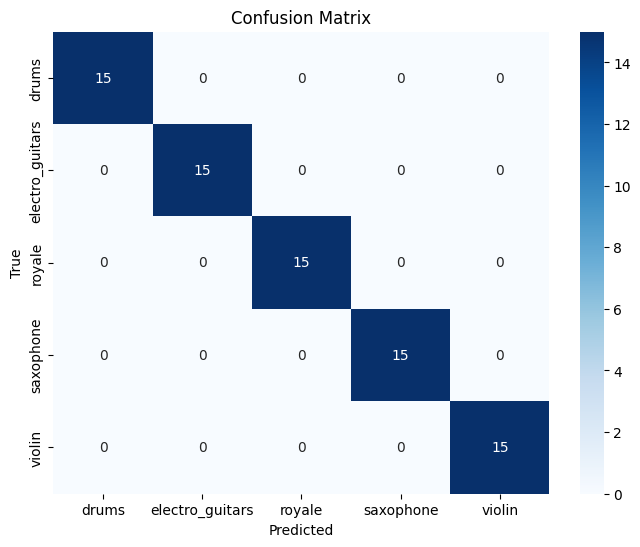

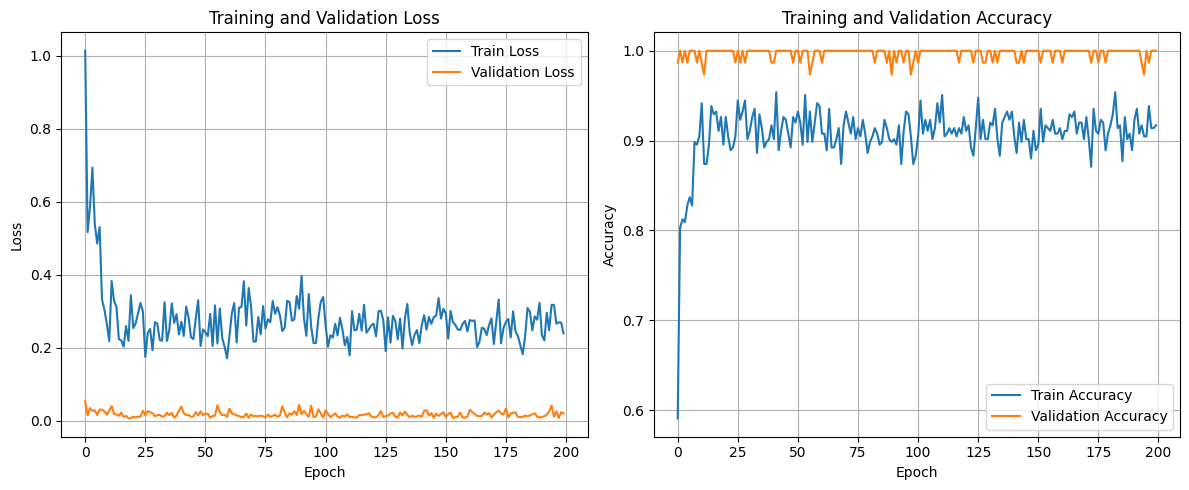

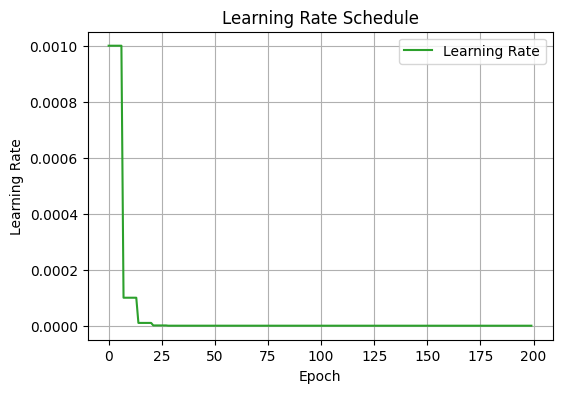

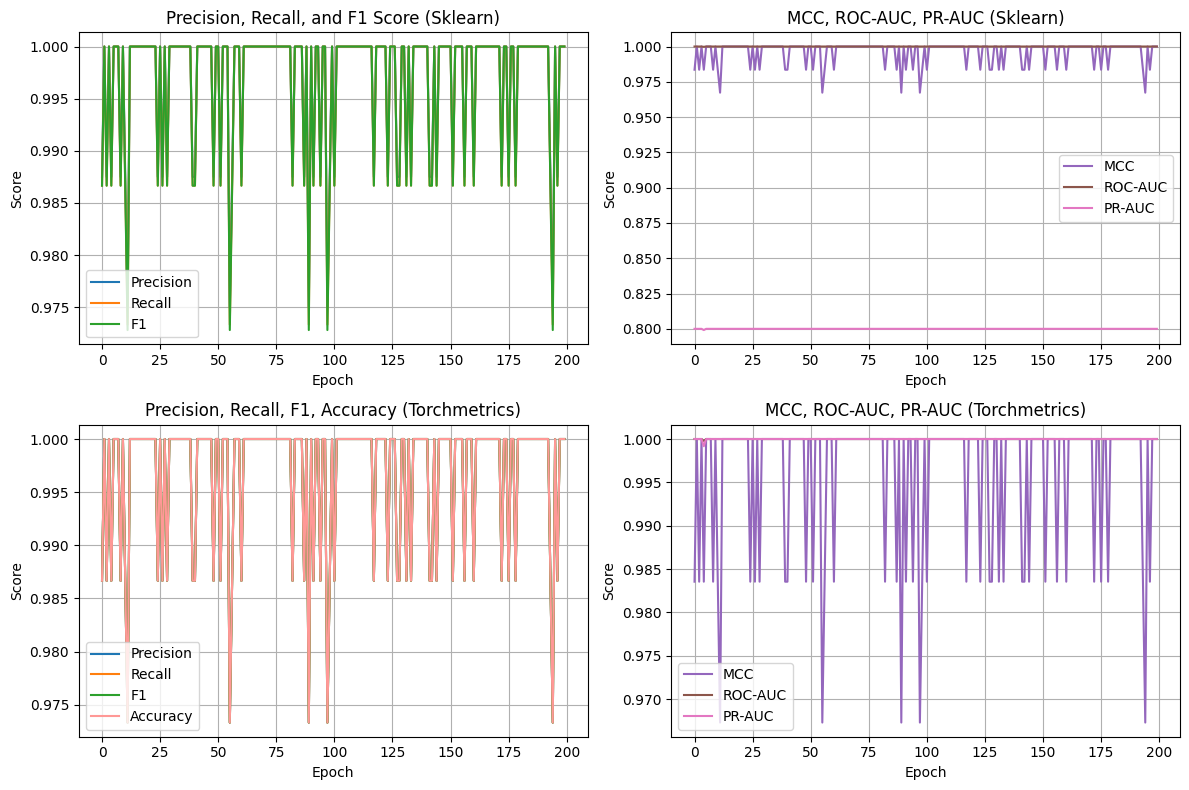

In [13]:
model_ft, metrics, learning_rates, val_metrics = train_model_new(
    model_ft, 
    criterion, 
    optimizer_ft, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics_new(
    metrics, 
    learning_rates, 
    val_metrics, 
    plot_roc_pr=True
)

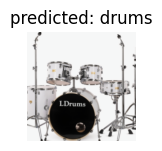

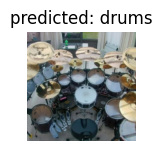

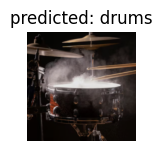

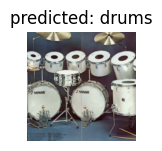

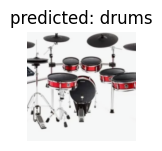

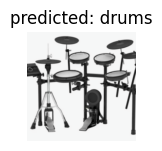

In [14]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor

### Here, we need to freeze all the network except the final layer. We need to set requires_grad = False to freeze the parameters so that the gradients are not computed in backward().

In [15]:
model_conv: nn.Module = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs: int = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, num_classes)

model_conv = model_conv.to(device)

criterion: nn.Module = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv: optim.Optimizer = optim.SGD(
    model_conv.fc.parameters(), 
    lr=0.001, 
    momentum=0.9
)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer_conv, 
    step_size=7, 
    gamma=0.1
)

## Train and evaluate

### Тренировка для Music dataset при заморозке слоёв

Epoch 0/199
----------
Learning Rate: 0.001000
train Loss: 1.3115 Acc: 0.4677
val Loss: 0.2237 Acc: 0.9600
val Precision_skl: 0.9640, Recall_skl: 0.9600, F1_skl: 0.9588
val ROC-AUC_skl: 0.9996, PR-AUC_skl: 0.7983
val Precision_torch: 0.9600, Recall_torch: 0.9600, F1_torch: 0.9600
val Accuracy_torch: 0.9600, MCC_torch: 0.9515
val ROC-AUC_torch: 0.9996, PR-AUC_torch: 0.9983

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.8003 Acc: 0.7108
val Loss: 0.1030 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 0.7359 Acc: 0.7200
val Loss: 0.0947 Acc: 0.9600
val Precision_skl: 0.9667, Recall_skl: 0.9600, F1_skl: 0.9611
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9600, Recall

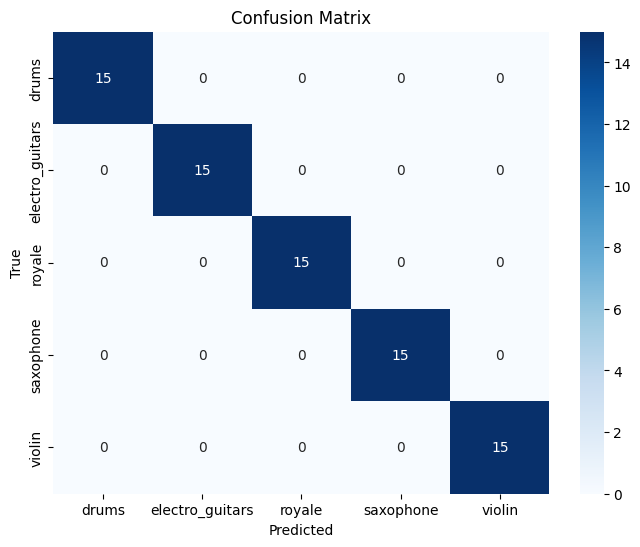

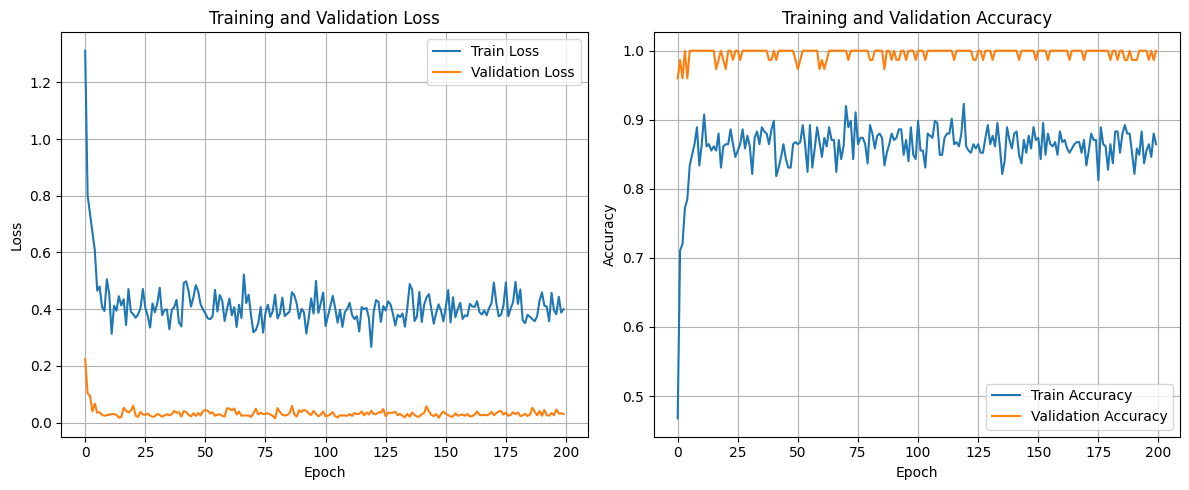

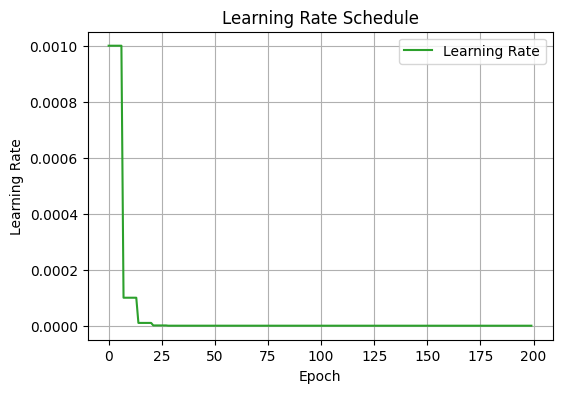

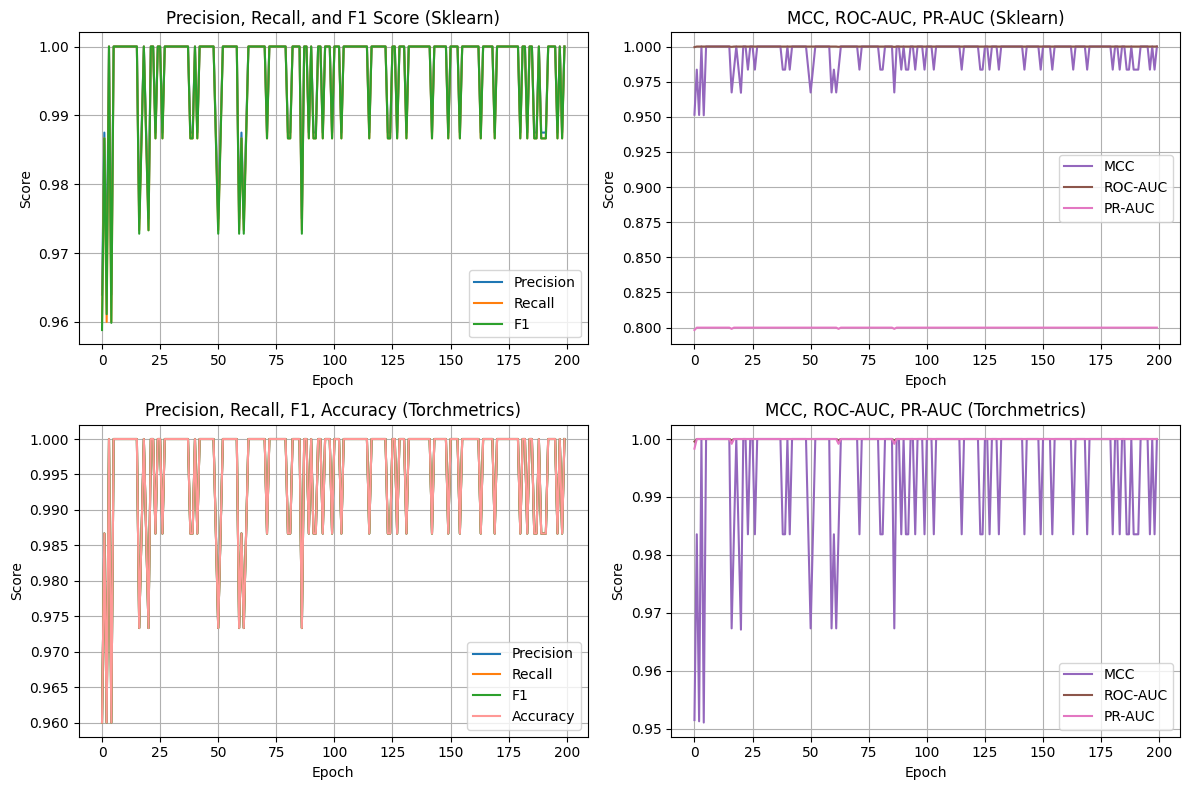

In [16]:
model_conv, metrics, learning_rates, val_metrics = train_model_new(
    model_conv, 
    criterion, 
    optimizer_conv, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics_new(
    metrics, 
    learning_rates, 
    val_metrics, 
    plot_roc_pr=True
)

## Visualising

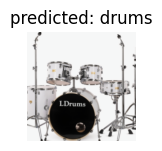

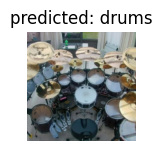

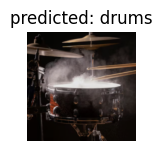

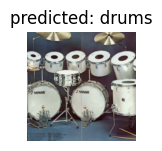

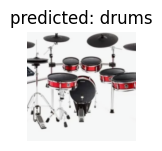

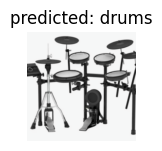

In [17]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [18]:
def evaluate_on_test(
    model, 
    test_loader, 
    class_names, 
    device: str
):
    """
    Финальная оценка модели на test датасете
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_probs = np.array(all_probs)
    
    # Метрики на test
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )
    mcc = matthews_corrcoef(all_labels, all_preds)
    
    print("\n" + "="*50)
    print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ")
    print("="*50)
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision (macro): {precision:.4f}")
    print(f"Test Recall (macro): {recall:.4f}")
    print(f"Test F1 (macro): {f1:.4f}")
    print(f"Test MCC: {mcc:.4f}")
    
    # Матрица ошибок
    plot_confusion_matrix(all_labels, all_preds, class_names)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mcc': mcc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }


### Тестирование лучшей модели перед экспериментом


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


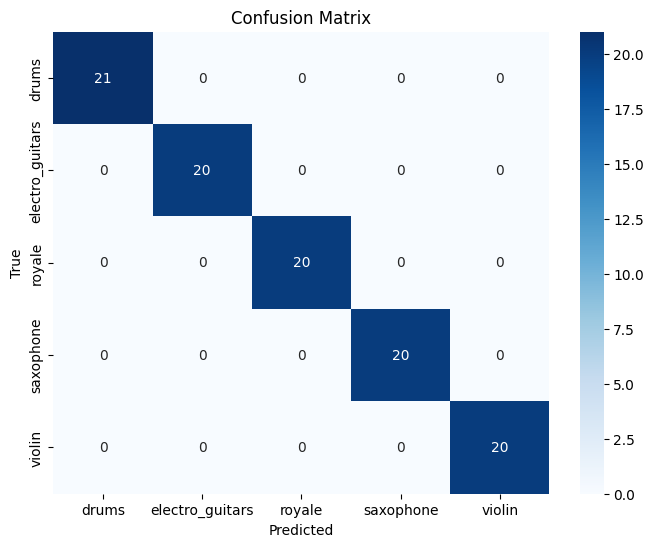

In [19]:
best_model: Any = model_ft  # или model_conv - лучшая модель после экспериментов
test_results = evaluate_on_test(
    best_model, 
    dataloaders['test'], 
    class_names, 
    device
)

In [20]:
test_results

{'accuracy': np.float64(1.0),
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'mcc': 1.0,
 'predictions': [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64

## Inference on custom images

In [21]:
def visualize_model_predictions(
    model: nn.Module, 
    img_path: str
) -> None:
    was_training: bool = model.training
    model.eval()

    # img: Image.Image = Image.open(img_path)
    img: Image.Image = Image.open(img_path).convert('RGB')
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs: torch.Tensor = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

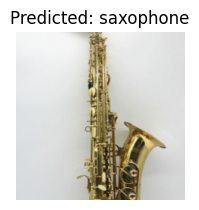

In [22]:
visualize_model_predictions(
    model_conv,
    # img_path='./../data/hymenoptera_data/val/bees/26589803_5ba7000313.jpg'
    img_path='./../data/music_dataset/val/saxophone/sax_69.png'
)

plt.ioff()
plt.show()

## Исследования

### Исследование 1: Learning Rate


Тестирование learning rate = 0.1
Epoch 0/49
----------
Learning Rate: 0.100000
train Loss: 15.3976 Acc: 0.2062
val Loss: 3.2809 Acc: 0.1867
val Precision_skl: 0.0406, Recall_skl: 0.1867, F1_skl: 0.0667
val ROC-AUC_skl: 0.6111, PR-AUC_skl: 0.0433
val Precision_torch: 0.1867, Recall_torch: 0.1867, F1_torch: 0.1867
val Accuracy_torch: 0.1867, MCC_torch: -0.0389
val ROC-AUC_torch: 0.6111, PR-AUC_torch: 0.2733

Epoch 1/49
----------
Learning Rate: 0.100000
train Loss: 1.6279 Acc: 0.2708
val Loss: 3.7703 Acc: 0.1600
val Precision_skl: 0.0584, Recall_skl: 0.1600, F1_skl: 0.0852
val ROC-AUC_skl: 0.5156, PR-AUC_skl: 0.0195
val Precision_torch: 0.1600, Recall_torch: 0.1600, F1_torch: 0.1600
val Accuracy_torch: 0.1600, MCC_torch: -0.0642
val ROC-AUC_torch: 0.5156, PR-AUC_torch: 0.2426

Epoch 2/49
----------
Learning Rate: 0.100000
train Loss: 1.6368 Acc: 0.2492
val Loss: 4.1998 Acc: 0.2667
val Precision_skl: 0.1789, Recall_skl: 0.2667, F1_skl: 0.2014
val ROC-AUC_skl: 0.6644, PR-AUC_skl: 0.1860
v

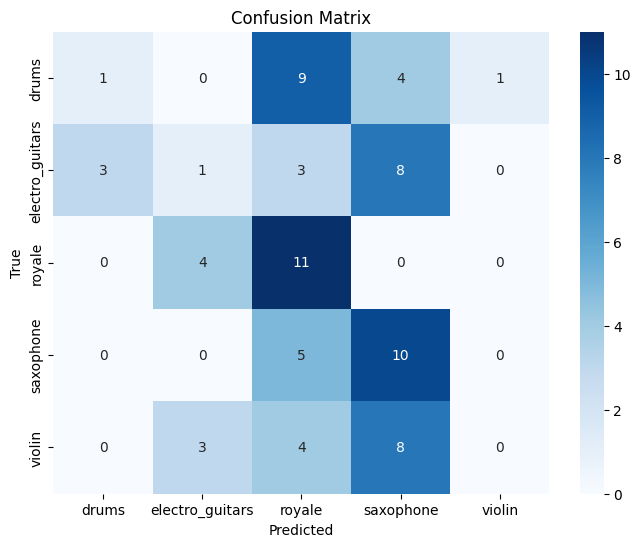


--- Итог для lr=0.1 ---
Финальная train accuracy: 0.3323
Финальная val accuracy: 0.3067
Лучшая val accuracy: 0.3200

Тестирование learning rate = 0.01
Epoch 0/49
----------
Learning Rate: 0.010000
train Loss: 4.6247 Acc: 0.2554
val Loss: 2.3249 Acc: 0.2000
val Precision_skl: 0.0400, Recall_skl: 0.2000, F1_skl: 0.0667
val ROC-AUC_skl: 0.4756, PR-AUC_skl: 0.0898
val Precision_torch: 0.2000, Recall_torch: 0.2000, F1_torch: 0.2000
val Accuracy_torch: 0.2000, MCC_torch: 0.0000
val ROC-AUC_torch: 0.4756, PR-AUC_torch: 0.3054

Epoch 1/49
----------
Learning Rate: 0.010000
train Loss: 3.8490 Acc: 0.2646
val Loss: 1.7320 Acc: 0.2000
val Precision_skl: 0.0400, Recall_skl: 0.2000, F1_skl: 0.0667
val ROC-AUC_skl: 0.5893, PR-AUC_skl: 0.1388
val Precision_torch: 0.2000, Recall_torch: 0.2000, F1_torch: 0.2000
val Accuracy_torch: 0.2000, MCC_torch: 0.0000
val ROC-AUC_torch: 0.5893, PR-AUC_torch: 0.3556

Epoch 2/49
----------
Learning Rate: 0.010000
train Loss: 2.6295 Acc: 0.2185
val Loss: 4.2967 Acc:

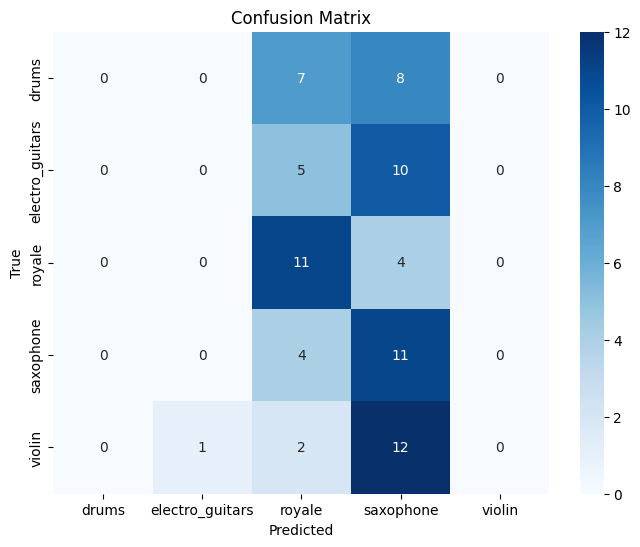


--- Итог для lr=0.01 ---
Финальная train accuracy: 0.2738
Финальная val accuracy: 0.2933
Лучшая val accuracy: 0.3200

Тестирование learning rate = 0.001
Epoch 0/49
----------
Learning Rate: 0.001000
train Loss: 1.0786 Acc: 0.5846
val Loss: 0.0367 Acc: 1.0000
val Precision_skl: 1.0000, Recall_skl: 1.0000, F1_skl: 1.0000
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 1.0000, Recall_torch: 1.0000, F1_torch: 1.0000
val Accuracy_torch: 1.0000, MCC_torch: 1.0000
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 1/49
----------
Learning Rate: 0.001000
train Loss: 0.6043 Acc: 0.7754
val Loss: 0.0279 Acc: 1.0000
val Precision_skl: 1.0000, Recall_skl: 1.0000, F1_skl: 1.0000
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 1.0000, Recall_torch: 1.0000, F1_torch: 1.0000
val Accuracy_torch: 1.0000, MCC_torch: 1.0000
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 2/49
----------
Learning Rate: 0.001000
train Loss: 0.5194 Acc: 0.8185
val Loss: 0.0297 Ac

train Loss: 0.2922 Acc: 0.9231
val Loss: 0.0220 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Early stopping triggered.
Training complete in 0m 29s
Best val Acc: 0.986667


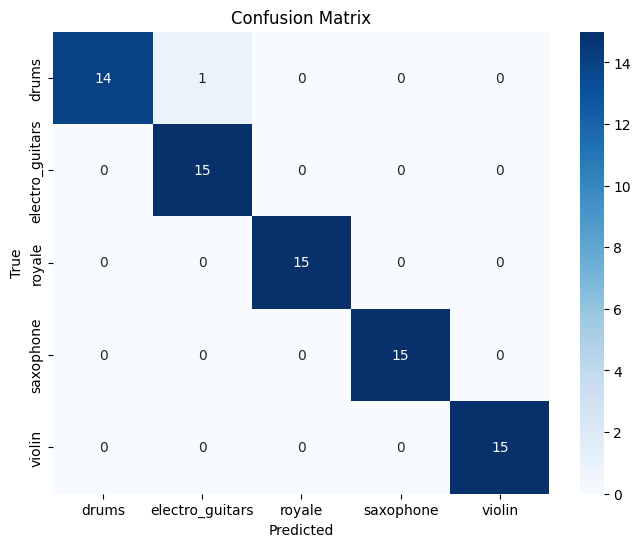


--- Итог для lr=0.001 ---
Финальная train accuracy: 0.9231
Финальная val accuracy: 0.9867
Лучшая val accuracy: 1.0000

Тестирование learning rate = 0.0001
Epoch 0/49
----------
Learning Rate: 0.000100
train Loss: 1.5352 Acc: 0.3631
val Loss: 1.0573 Acc: 0.6800
val Precision_skl: 0.7692, Recall_skl: 0.6800, F1_skl: 0.6585
val ROC-AUC_skl: 0.9349, PR-AUC_skl: 0.6473
val Precision_torch: 0.6800, Recall_torch: 0.6800, F1_torch: 0.6800
val Accuracy_torch: 0.6800, MCC_torch: 0.6290
val ROC-AUC_torch: 0.9349, PR-AUC_torch: 0.8515

Epoch 1/49
----------
Learning Rate: 0.000100
train Loss: 1.0894 Acc: 0.7323
val Loss: 0.5348 Acc: 0.9200
val Precision_skl: 0.9375, Recall_skl: 0.9200, F1_skl: 0.9199
val ROC-AUC_skl: 0.9969, PR-AUC_skl: 0.7890
val Precision_torch: 0.9200, Recall_torch: 0.9200, F1_torch: 0.9200
val Accuracy_torch: 0.9200, MCC_torch: 0.9046
val ROC-AUC_torch: 0.9969, PR-AUC_torch: 0.9893

Epoch 2/49
----------
Learning Rate: 0.000100
train Loss: 0.8942 Acc: 0.7446
val Loss: 0.3125 

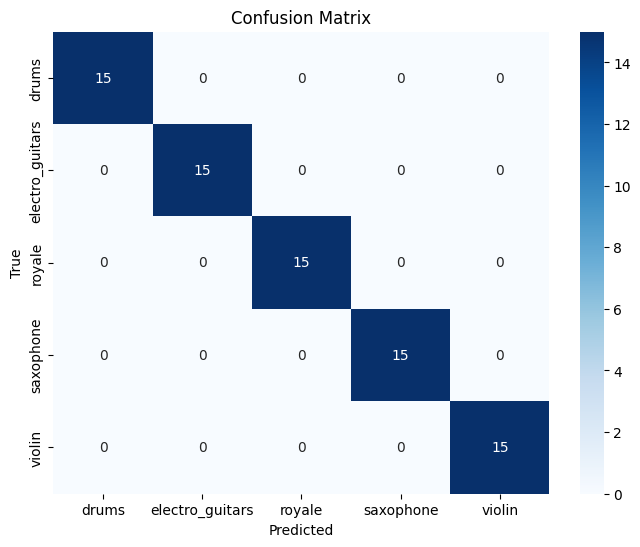


--- Итог для lr=0.0001 ---
Финальная train accuracy: 0.8123
Финальная val accuracy: 1.0000
Лучшая val accuracy: 1.0000

Тестирование learning rate = 1e-05
Epoch 0/49
----------
Learning Rate: 0.000010
train Loss: 1.6281 Acc: 0.2369
val Loss: 1.6441 Acc: 0.2133
val Precision_skl: 0.2170, Recall_skl: 0.2133, F1_skl: 0.2080
val ROC-AUC_skl: 0.5658, PR-AUC_skl: 0.0432
val Precision_torch: 0.2133, Recall_torch: 0.2133, F1_torch: 0.2133
val Accuracy_torch: 0.2133, MCC_torch: 0.0169
val ROC-AUC_torch: 0.5658, PR-AUC_torch: 0.2651

Epoch 1/49
----------
Learning Rate: 0.000010
train Loss: 1.5484 Acc: 0.2554
val Loss: 1.5402 Acc: 0.2533
val Precision_skl: 0.2455, Recall_skl: 0.2533, F1_skl: 0.2222
val ROC-AUC_skl: 0.6371, PR-AUC_skl: 0.1395
val Precision_torch: 0.2533, Recall_torch: 0.2533, F1_torch: 0.2533
val Accuracy_torch: 0.2533, MCC_torch: 0.0698
val ROC-AUC_torch: 0.6371, PR-AUC_torch: 0.3609

Epoch 2/49
----------
Learning Rate: 0.000010
train Loss: 1.5078 Acc: 0.3323
val Loss: 1.4928 

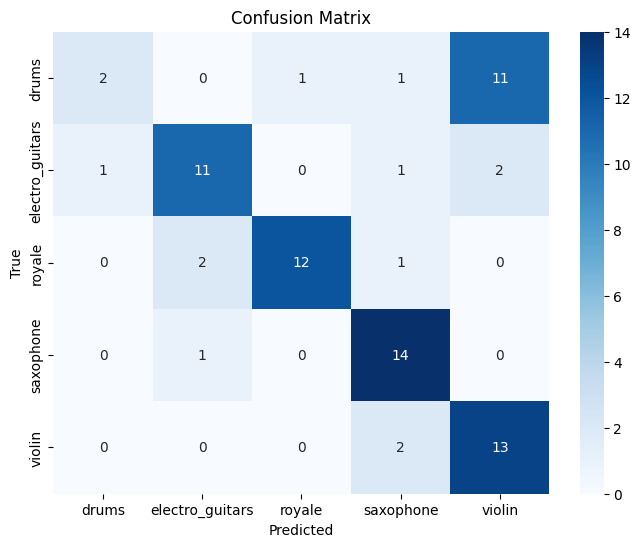


--- Итог для lr=1e-05 ---
Финальная train accuracy: 0.5600
Финальная val accuracy: 0.6933
Лучшая val accuracy: 0.7067

Тестирование learning rate = 1e-06
Epoch 0/49
----------
Learning Rate: 0.000001
train Loss: 1.6140 Acc: 0.3108
val Loss: 1.5972 Acc: 0.3733
val Precision_skl: 0.4515, Recall_skl: 0.3733, F1_skl: 0.3283
val ROC-AUC_skl: 0.6360, PR-AUC_skl: 0.1772
val Precision_torch: 0.3733, Recall_torch: 0.3733, F1_torch: 0.3733
val Accuracy_torch: 0.3733, MCC_torch: 0.2411
val ROC-AUC_torch: 0.6360, PR-AUC_torch: 0.3925

Epoch 1/49
----------
Learning Rate: 0.000001
train Loss: 1.6007 Acc: 0.3262
val Loss: 1.5658 Acc: 0.3200
val Precision_skl: 0.4061, Recall_skl: 0.3200, F1_skl: 0.2716
val ROC-AUC_skl: 0.6524, PR-AUC_skl: 0.2107
val Precision_torch: 0.3200, Recall_torch: 0.3200, F1_torch: 0.3200
val Accuracy_torch: 0.3200, MCC_torch: 0.1635
val ROC-AUC_torch: 0.6524, PR-AUC_torch: 0.4244

Epoch 2/49
----------
Learning Rate: 0.000001
train Loss: 1.6047 Acc: 0.3077
val Loss: 1.5853 A

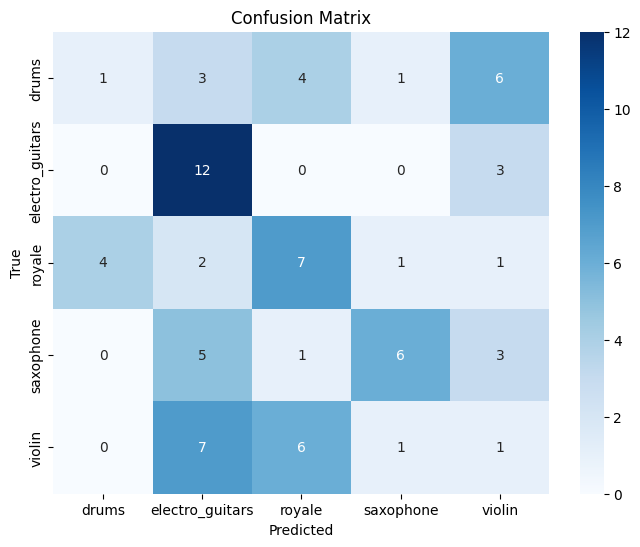


--- Итог для lr=1e-06 ---
Финальная train accuracy: 0.3877
Финальная val accuracy: 0.3600
Лучшая val accuracy: 0.3733

Тестирование learning rate = 1e-07
Epoch 0/49
----------
Learning Rate: 0.000000
train Loss: 1.8942 Acc: 0.2277
val Loss: 1.9563 Acc: 0.2133
val Precision_skl: 0.1121, Recall_skl: 0.2133, F1_skl: 0.1247
val ROC-AUC_skl: 0.5076, PR-AUC_skl: 0.0414
val Precision_torch: 0.2133, Recall_torch: 0.2133, F1_torch: 0.2133
val Accuracy_torch: 0.2133, MCC_torch: 0.0265
val ROC-AUC_torch: 0.5076, PR-AUC_torch: 0.2596

Epoch 1/49
----------
Learning Rate: 0.000000
train Loss: 1.8800 Acc: 0.2062
val Loss: 1.9582 Acc: 0.2533
val Precision_skl: 0.1305, Recall_skl: 0.2533, F1_skl: 0.1540
val ROC-AUC_skl: 0.5296, PR-AUC_skl: 0.0425
val Precision_torch: 0.2533, Recall_torch: 0.2533, F1_torch: 0.2533
val Accuracy_torch: 0.2533, MCC_torch: 0.0986
val ROC-AUC_torch: 0.5296, PR-AUC_torch: 0.2627

Epoch 2/49
----------
Learning Rate: 0.000000
train Loss: 1.8787 Acc: 0.2092
val Loss: 1.9185 A

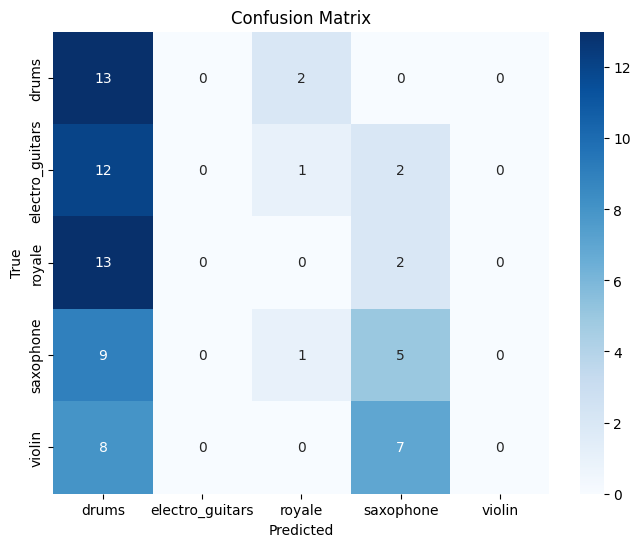


--- Итог для lr=1e-07 ---
Финальная train accuracy: 0.2338
Финальная val accuracy: 0.2400
Лучшая val accuracy: 0.2800


In [23]:
learning_rates: List[float] = [0.1, 0.01, 0.001, 0.0001, 1e-5, 1e-6, 1e-7]
results_lr = {}

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Тестирование learning rate = {lr}")
    print('='*50)
    
    # Создаем модель
    model: nn.Module = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs: int = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)
    
    criterion:  nn.CrossEntropyLoss = nn.CrossEntropyLoss()
    optimizer: optim.SGD = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    scheduler: lr_scheduler.StepLR = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    # Обучаем
    model, metrics, lrs, val_metrics = train_model_new(
        model, 
        criterion, 
        optimizer, 
        scheduler, 
        num_epochs=50, 
        patience=10
    )
    
    results_lr[lr] = {
        'model': model,
        'metrics': metrics,
        'val_metrics': val_metrics,
        'final_val_acc': metrics['val_acc'][-1] if metrics['val_acc'] else 0,
        'best_val_acc': max(metrics['val_acc']) if metrics['val_acc'] else 0,
        'final_train_acc': metrics['train_acc'][-1] if metrics['train_acc'] else 0
    }
    
    # Сохраняем результаты
    torch.save(model.state_dict(), f'model_lr_{lr}.pth')
    print(f"\n--- Итог для lr={lr} ---")
    print(f"Финальная train accuracy: {results_lr[lr]['final_train_acc']:.4f}")
    print(f"Финальная val accuracy: {results_lr[lr]['final_val_acc']:.4f}")
    print(f"Лучшая val accuracy: {results_lr[lr]['best_val_acc']:.4f}")

In [27]:
print("\n" + "="*60)
print("СРАВНЕНИЕ ВСЕХ LEARNING RATES")
print("="*60)

# Таблица результатов
print(f"\n{'LR':<12} {'Train Acc':<12} {'Val Acc':<12} {'Best Val':<12}")
print("-"*48)
for lr in learning_rates:
    print(f"{lr:<12} {results_lr[lr]['final_train_acc']:<12.4f} "
          f"{results_lr[lr]['final_val_acc']:<12.4f} "
          f"{results_lr[lr]['best_val_acc']:<12.4f}")

# Находим лучший learning rate
best_lr: float = max(results_lr, key=lambda x: results_lr[x]['final_val_acc'])
print(f"\n🏆 Лучший learning rate: {best_lr} с val accuracy = {results_lr[best_lr]['best_val_acc']:.4f}")


СРАВНЕНИЕ ВСЕХ LEARNING RATES

LR           Train Acc    Val Acc      Best Val    
------------------------------------------------
0.1          0.3323       0.3067       0.3200      
0.01         0.2738       0.2933       0.3200      
0.001        0.9231       0.9867       1.0000      
0.0001       0.8123       1.0000       1.0000      
1e-05        0.5600       0.6933       0.7067      
1e-06        0.3877       0.3600       0.3733      
1e-07        0.2338       0.2400       0.2800      

🏆 Лучший learning rate: 0.0001 с val accuracy = 1.0000


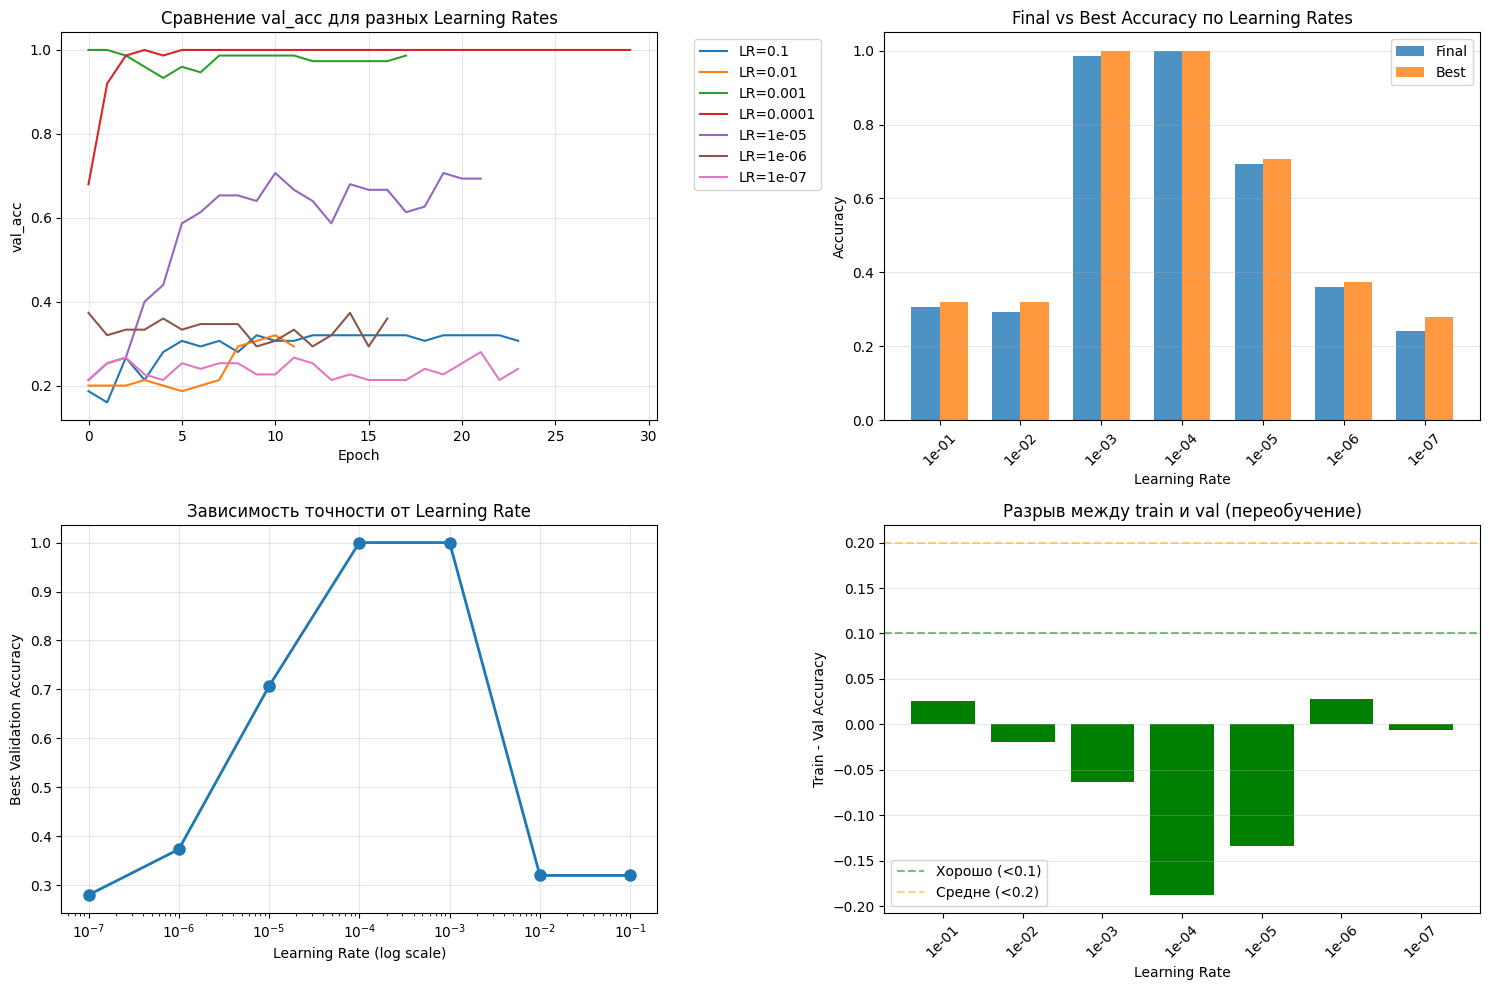

In [28]:
def plot_lr_comparison(
    results_lr: Dict[str, Any], 
    metric: str = 'val_acc'
) -> None:
    """
    Сравнение разных learning rates
    """
    plt.figure(figsize=(15, 10))
    
    # График 1: Сравнение всех кривых обучения
    plt.subplot(2, 2, 1)
    for lr, result in results_lr.items():
        plt.plot(result['metrics'][metric], label=f'LR={lr}', linewidth=1.5)
    plt.title(f'Сравнение {metric} для разных Learning Rates')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # График 2: Финальные значения
    plt.subplot(2, 2, 2)
    lrs = list(results_lr.keys())
    final_values = [results_lr[lr][f'final_{metric}'] for lr in lrs]
    best_values = [results_lr[lr]['best_val_acc'] for lr in lrs]
    
    x = range(len(lrs))
    width = 0.35
    plt.bar([i - width/2 for i in x], final_values, width, label='Final', color='#1f77b4', alpha=0.8)
    plt.bar([i + width/2 for i in x], best_values, width, label='Best', color='#ff7f0e', alpha=0.8)
    plt.xlabel('Learning Rate')
    plt.ylabel('Accuracy')
    plt.title('Final vs Best Accuracy по Learning Rates')
    plt.xticks(x, [f'{lr:.0e}' for lr in lrs], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    # График 3: Зависимость точности от LR (логарифмическая шкала)
    plt.subplot(2, 2, 3)
    plt.semilogx(list(results_lr.keys()), best_values, 'o-', linewidth=2, markersize=8)
    plt.xlabel('Learning Rate (log scale)')
    plt.ylabel('Best Validation Accuracy')
    plt.title('Зависимость точности от Learning Rate')
    plt.grid(True, alpha=0.3)
    
    # График 4: Разрыв между train и val (переобучение)
    plt.subplot(2, 2, 4)
    train_final = [results_lr[lr]['final_train_acc'] for lr in lrs]
    val_final = [results_lr[lr]['final_val_acc'] for lr in lrs]
    overfitting = [t - v for t, v in zip(train_final, val_final)]
    
    plt.bar(x, overfitting, color=['green' if o < 0.1 else 'orange' if o < 0.2 else 'red' for o in overfitting])
    plt.xlabel('Learning Rate')
    plt.ylabel('Train - Val Accuracy')
    plt.title('Разрыв между train и val (переобучение)')
    plt.xticks(x, [f'{lr:.0e}' for lr in lrs], rotation=45)
    plt.axhline(y=0.1, color='green', linestyle='--', alpha=0.5, label='Хорошо (<0.1)')
    plt.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, label='Средне (<0.2)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Вызываем функцию визуализации
plot_lr_comparison(results_lr, metric='val_acc')

### Исследование 2: Batch Size

In [29]:
def train_model_with_dataloaders(
    model_arch: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler._LRScheduler,
    dataloaders: Dict[str, torch.utils.data.DataLoader],
    dataset_sizes: Dict[str, int],
    num_epochs: int = 25,
    patience: int = 5
) -> Tuple[nn.Module, Dict[str, List[float]], List[float], Dict[str, List[float]]]:
    
    since = time.time()
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False

    # Метрики
    accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
    recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
    f1 = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
    mcc = MatthewsCorrCoef(task="multiclass", num_classes=num_classes).to(device)
    auroc = AUROC(task="multiclass", num_classes=num_classes).to(device)
    pr_auc = AveragePrecision(task="multiclass", num_classes=num_classes, average='macro').to(device)

    # Lists to store metrics
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    learning_rates = []
    val_metrics = {
        'precision_skl': [], 'recall_skl': [], 'f1_skl': [], 'mcc_skl': [], 
        'roc_auc_skl': [], 'pr_auc_skl': [],
        'accuracy_torch': [], 'precision_torch': [], 'recall_torch': [], 
        'f1_torch': [], 'mcc_torch': [], 'roc_auc_torch': [], 'pr_auc_torch': []
    }

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model_arch.state_dict(), best_model_params_path)
        
        for epoch in range(num_epochs):
            if early_stop:
                print("Early stopping triggered.")
                break
                
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            current_lr = optimizer.param_groups[0]['lr']
            learning_rates.append(current_lr)
            print(f'Learning Rate: {current_lr:.6f}')

            for phase in ['train', 'val']:
                if phase == 'train':
                    model_arch.train()
                else:
                    model_arch.eval()

                running_loss = 0.0
                running_corrects = 0
                all_preds, all_labels, all_probs = [], [], []

                # Reset metrics
                for metric in [accuracy, precision, recall, f1, mcc, auroc, pr_auc]:
                    metric.reset()

                for inputs, labels in dataloaders[phase]:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model_arch(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        probs = torch.softmax(outputs, dim=1)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).item()
                    
                    if phase == 'val':
                        all_preds.extend(preds.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())
                        all_probs.append(probs.cpu().numpy())

                    # Update torchmetrics
                    accuracy.update(preds, labels)
                    precision.update(preds, labels)
                    recall.update(preds, labels)
                    f1.update(preds, labels)
                    mcc.update(preds, labels)
                    auroc.update(probs, labels)
                    pr_auc.update(probs, labels)

                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects / dataset_sizes[phase]

                if phase == 'train':
                    train_losses.append(epoch_loss)
                    train_accuracies.append(epoch_acc)
                else:
                    val_losses.append(epoch_loss)
                    val_accuracies.append(epoch_acc)
                    
                    if epoch_loss < best_loss:
                        best_loss = epoch_loss
                        best_acc = epoch_acc
                        epochs_no_improve = 0
                        torch.save(model_arch.state_dict(), best_model_params_path)
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            early_stop = True

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and all_probs:
                    all_probs = np.vstack(all_probs)
                    
                    # Sklearn metrics
                    precision_skl, recall_skl, f1_skl, _ = precision_recall_fscore_support(
                        all_labels, all_preds, average='macro', zero_division=0
                    )
                    
                    mcc_skl = matthews_corrcoef(all_labels, all_preds)
                    
                    if len(all_probs) > 0:
                        roc_auc_skl = roc_auc_score(all_labels, all_probs, multi_class='ovr')
                        
                        # PR-AUC
                        pr_auc_skl = 0
                        for i in range(num_classes):
                            y_true_binary = [1 if label == i else 0 for label in all_labels]
                            y_score_binary = [prob[i] for prob in all_probs]
                            precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, y_score_binary)
                            pr_auc_skl += np.trapezoid(recall_curve, precision_curve)
                        pr_auc_skl /= num_classes
                    else:
                        roc_auc_skl, pr_auc_skl = 0.0, 0.0

                    # Store metrics
                    val_metrics['precision_skl'].append(precision_skl)
                    val_metrics['recall_skl'].append(recall_skl)
                    val_metrics['f1_skl'].append(f1_skl)
                    val_metrics['mcc_skl'].append(mcc_skl)
                    val_metrics['roc_auc_skl'].append(roc_auc_skl)
                    val_metrics['pr_auc_skl'].append(pr_auc_skl)

                    # Torchmetrics
                    val_metrics['accuracy_torch'].append(accuracy.compute().item())
                    val_metrics['precision_torch'].append(precision.compute().item())
                    val_metrics['recall_torch'].append(recall.compute().item())
                    val_metrics['f1_torch'].append(f1.compute().item())
                    val_metrics['mcc_torch'].append(mcc.compute().item())
                    val_metrics['roc_auc_torch'].append(auroc.compute().item())
                    val_metrics['pr_auc_torch'].append(pr_auc.compute().item())

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        model_arch.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    
    if all_preds and all_labels:
        plot_confusion_matrix(all_labels, all_preds, class_names)

    metrics = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }
    return model_arch, metrics, learning_rates, val_metrics

In [30]:
def visualize_model_optimized(
    model: nn.Module,
    dataloader: Dict[str, torch.utils.data.DataLoader],
    num_images: int = 6
) -> None:
    was_training: bool = model.training
    model.eval()
    images_so_far: int = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs: torch.Tensor = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


Тестирование batch size = 4
Пример батча (batch_size=4):


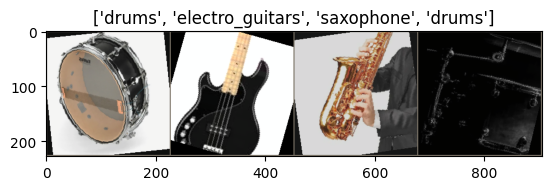

Epoch 0/49
----------
Learning Rate: 0.001000
train Loss: 0.9638 Acc: 0.6123
val Loss: 0.1333 Acc: 0.9600

Epoch 1/49
----------
Learning Rate: 0.001000
train Loss: 0.5973 Acc: 0.7908
val Loss: 0.1397 Acc: 0.9467

Epoch 2/49
----------
Learning Rate: 0.001000
train Loss: 0.5813 Acc: 0.8062
val Loss: 0.0412 Acc: 1.0000

Epoch 3/49
----------
Learning Rate: 0.001000
train Loss: 0.6612 Acc: 0.8031
val Loss: 0.0439 Acc: 0.9867

Epoch 4/49
----------
Learning Rate: 0.001000
train Loss: 0.6421 Acc: 0.7877
val Loss: 0.0154 Acc: 1.0000

Epoch 5/49
----------
Learning Rate: 0.001000
train Loss: 0.4863 Acc: 0.8400
val Loss: 0.0318 Acc: 0.9733

Epoch 6/49
----------
Learning Rate: 0.001000
train Loss: 0.4295 Acc: 0.8738
val Loss: 0.0560 Acc: 0.9733

Epoch 7/49
----------
Learning Rate: 0.000100
train Loss: 0.4010 Acc: 0.8862
val Loss: 0.0171 Acc: 1.0000

Epoch 8/49
----------
Learning Rate: 0.000100
train Loss: 0.2312 Acc: 0.9415
val Loss: 0.0310 Acc: 1.0000

Epoch 9/49
----------
Learning Rate: 

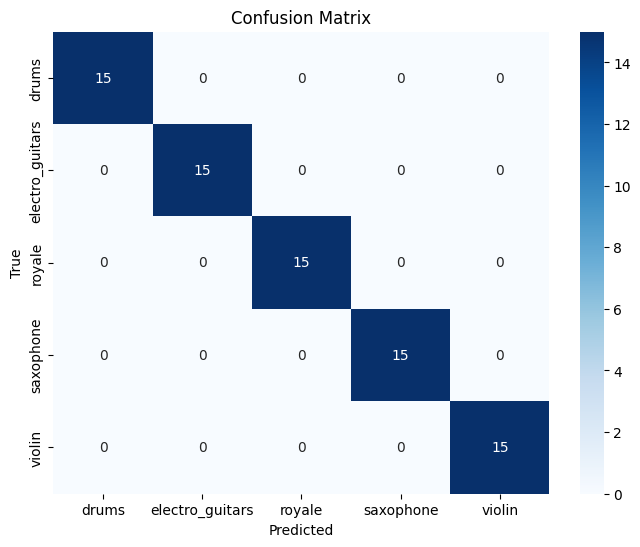

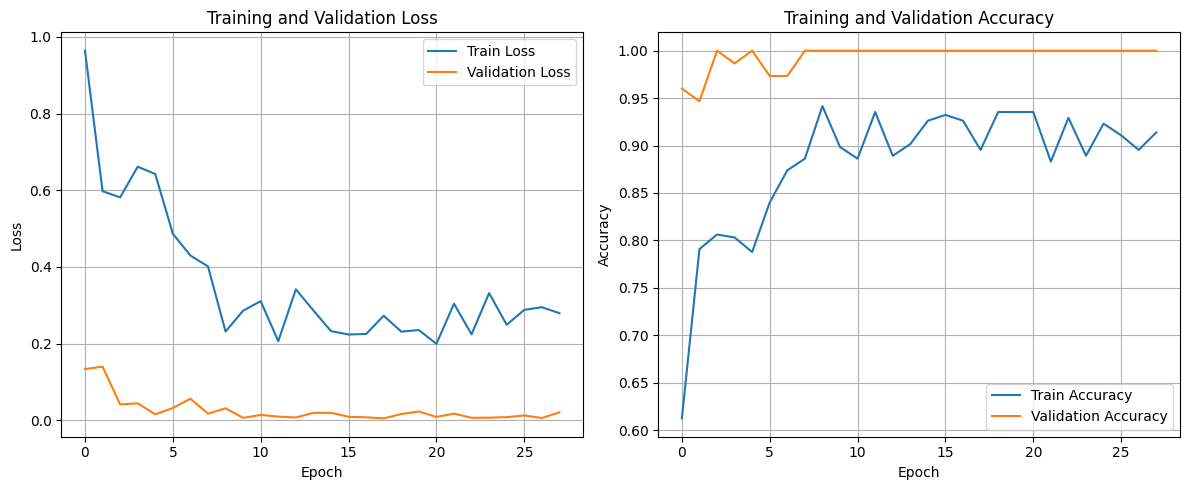

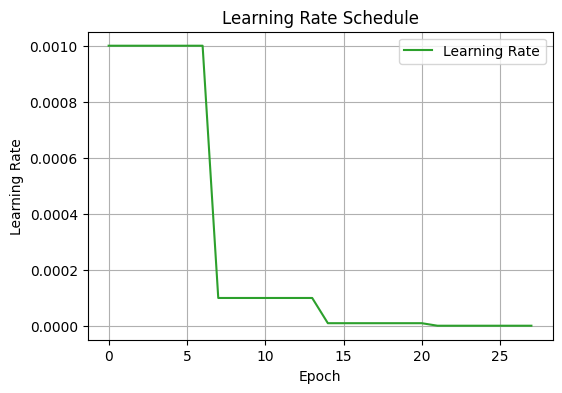

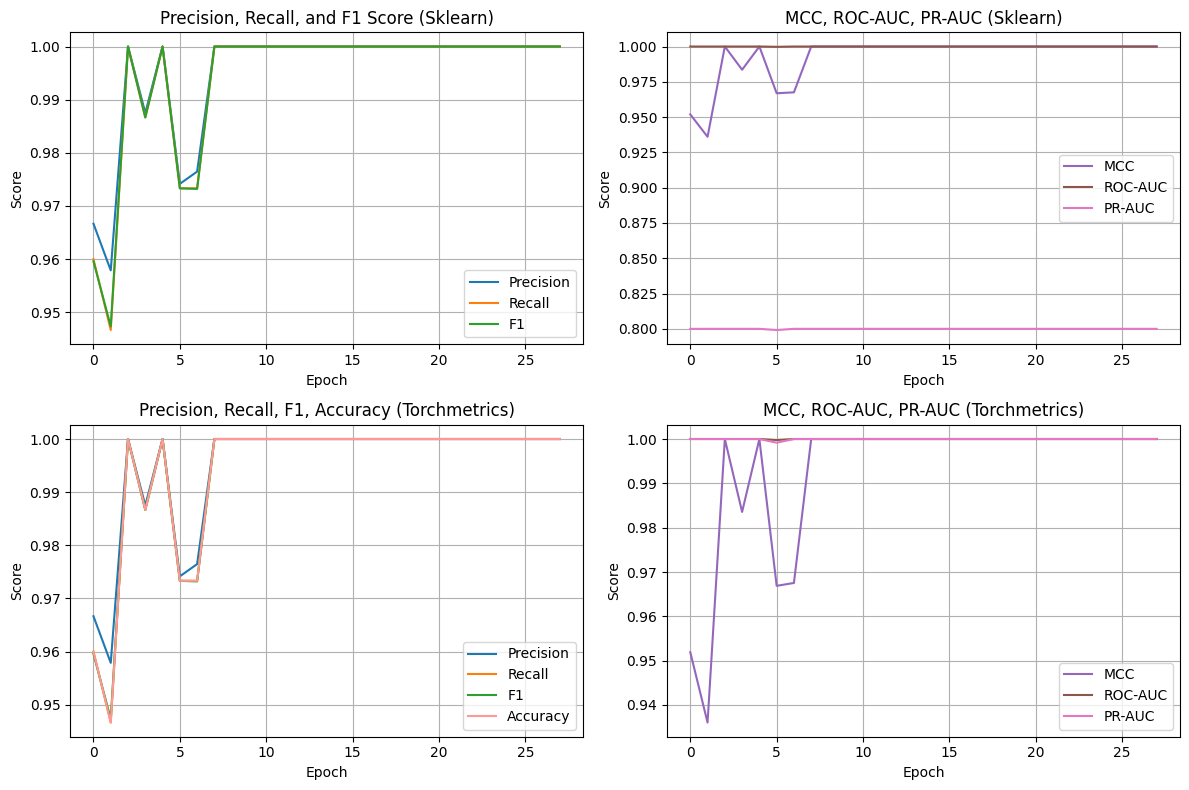


--- Визуализация для batch_size=4 ---


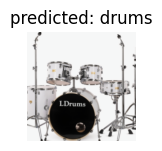

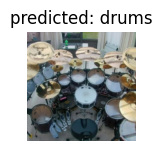

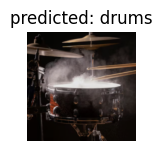

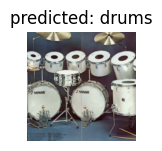

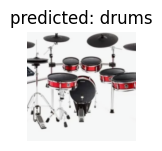

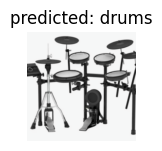


✅ Batch size 4 завершен. Лучшая val acc: 1.0000

Тестирование batch size = 8
Пример батча (batch_size=8):


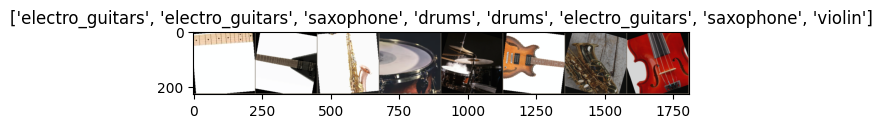

Epoch 0/49
----------
Learning Rate: 0.001000
train Loss: 1.0761 Acc: 0.5969
val Loss: 0.1111 Acc: 0.9867

Epoch 1/49
----------
Learning Rate: 0.001000
train Loss: 0.3800 Acc: 0.8800
val Loss: 0.0440 Acc: 1.0000

Epoch 2/49
----------
Learning Rate: 0.001000
train Loss: 0.3223 Acc: 0.8985
val Loss: 0.0253 Acc: 1.0000

Epoch 3/49
----------
Learning Rate: 0.001000
train Loss: 0.2787 Acc: 0.8954
val Loss: 0.0382 Acc: 1.0000

Epoch 4/49
----------
Learning Rate: 0.001000
train Loss: 0.2337 Acc: 0.9323
val Loss: 0.0087 Acc: 1.0000

Epoch 5/49
----------
Learning Rate: 0.001000
train Loss: 0.2631 Acc: 0.9077
val Loss: 0.0230 Acc: 1.0000

Epoch 6/49
----------
Learning Rate: 0.001000
train Loss: 0.1670 Acc: 0.9538
val Loss: 0.0221 Acc: 1.0000

Epoch 7/49
----------
Learning Rate: 0.000100
train Loss: 0.1853 Acc: 0.9446
val Loss: 0.0142 Acc: 1.0000

Epoch 8/49
----------
Learning Rate: 0.000100
train Loss: 0.1946 Acc: 0.9292
val Loss: 0.0191 Acc: 1.0000

Epoch 9/49
----------
Learning Rate: 

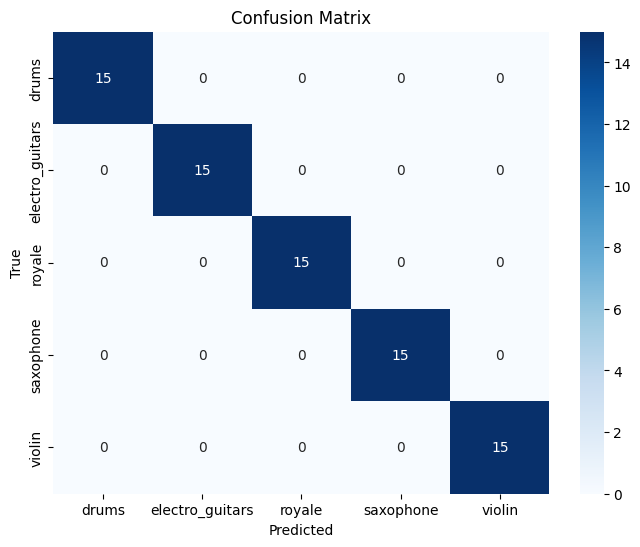

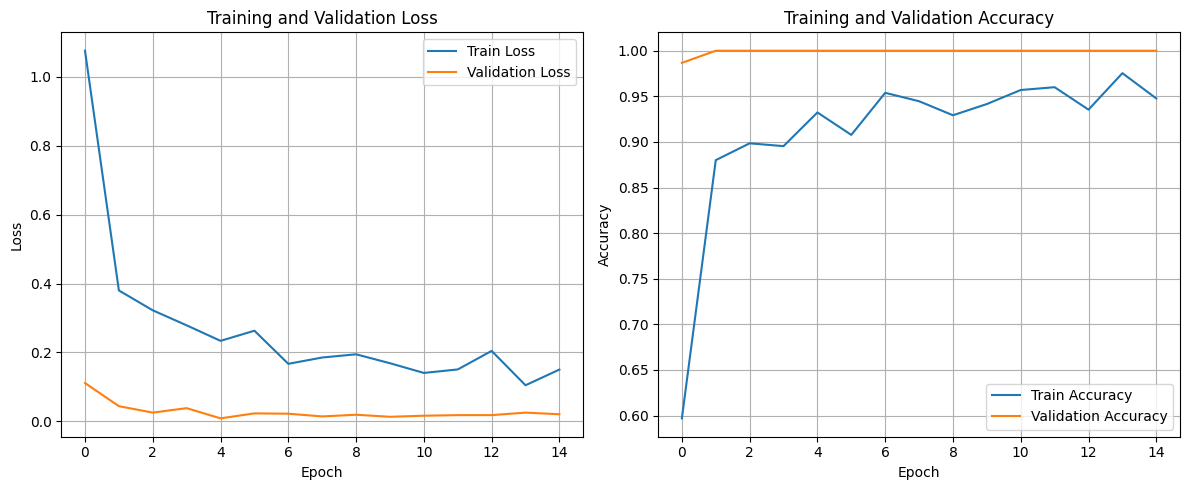

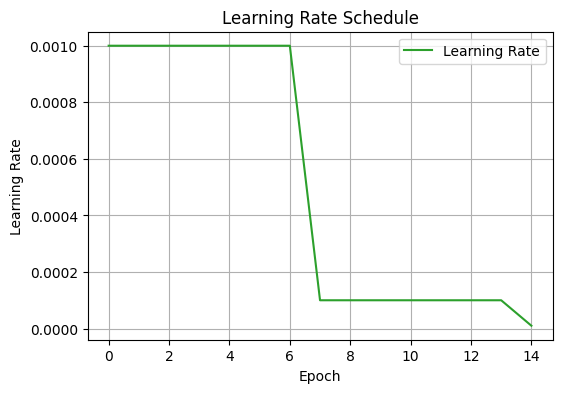

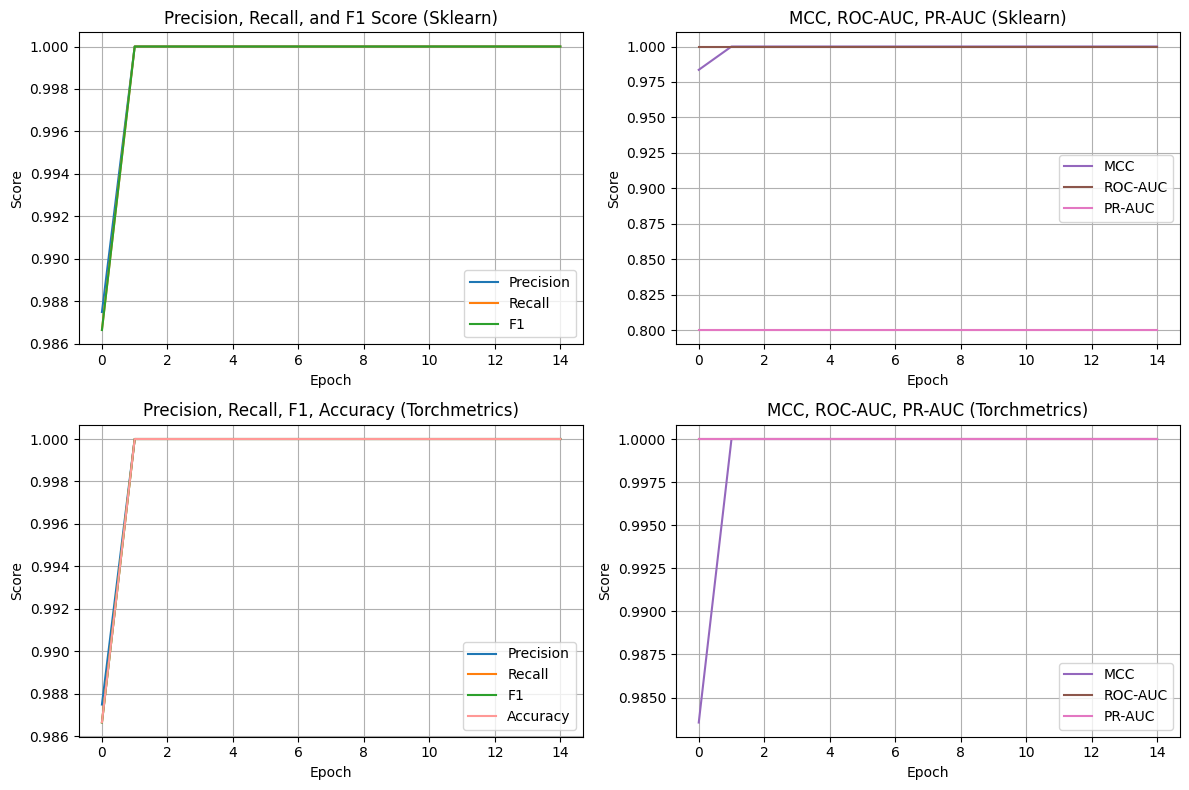


--- Визуализация для batch_size=8 ---


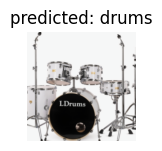

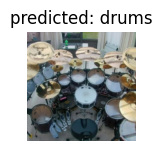

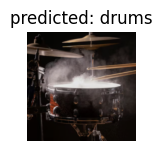

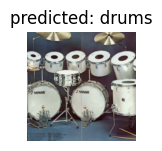

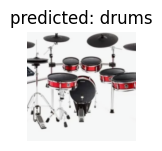

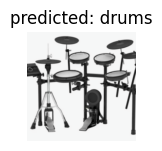


✅ Batch size 8 завершен. Лучшая val acc: 1.0000

Тестирование batch size = 16
Пример батча (batch_size=16):


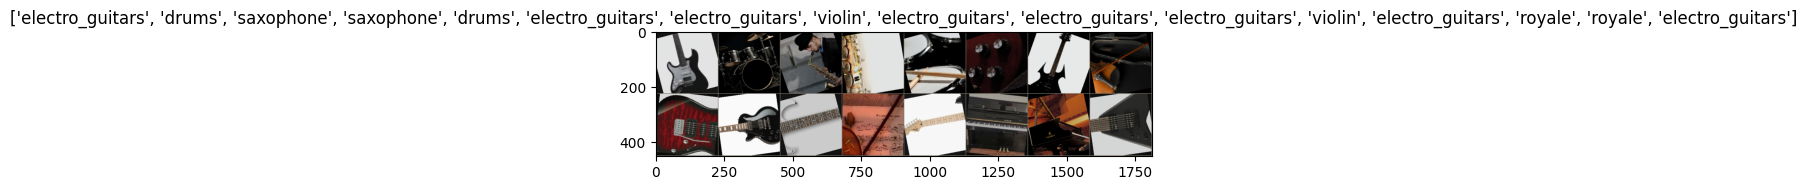

Epoch 0/49
----------
Learning Rate: 0.001000
train Loss: 1.3731 Acc: 0.4338
val Loss: 0.4862 Acc: 0.9333

Epoch 1/49
----------
Learning Rate: 0.001000
train Loss: 0.5159 Acc: 0.8585
val Loss: 0.1375 Acc: 0.9867

Epoch 2/49
----------
Learning Rate: 0.001000
train Loss: 0.2814 Acc: 0.9262
val Loss: 0.0725 Acc: 0.9867

Epoch 3/49
----------
Learning Rate: 0.001000
train Loss: 0.2533 Acc: 0.9200
val Loss: 0.0588 Acc: 0.9867

Epoch 4/49
----------
Learning Rate: 0.001000
train Loss: 0.1654 Acc: 0.9446
val Loss: 0.0515 Acc: 0.9867

Epoch 5/49
----------
Learning Rate: 0.001000
train Loss: 0.1770 Acc: 0.9508
val Loss: 0.0389 Acc: 1.0000

Epoch 6/49
----------
Learning Rate: 0.001000
train Loss: 0.1598 Acc: 0.9538
val Loss: 0.0246 Acc: 1.0000

Epoch 7/49
----------
Learning Rate: 0.000100
train Loss: 0.1595 Acc: 0.9631
val Loss: 0.0299 Acc: 1.0000

Epoch 8/49
----------
Learning Rate: 0.000100
train Loss: 0.1246 Acc: 0.9692
val Loss: 0.0321 Acc: 1.0000

Epoch 9/49
----------
Learning Rate: 

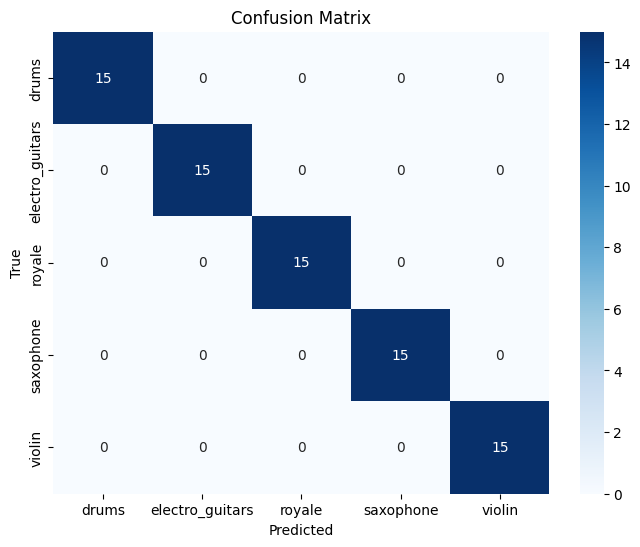

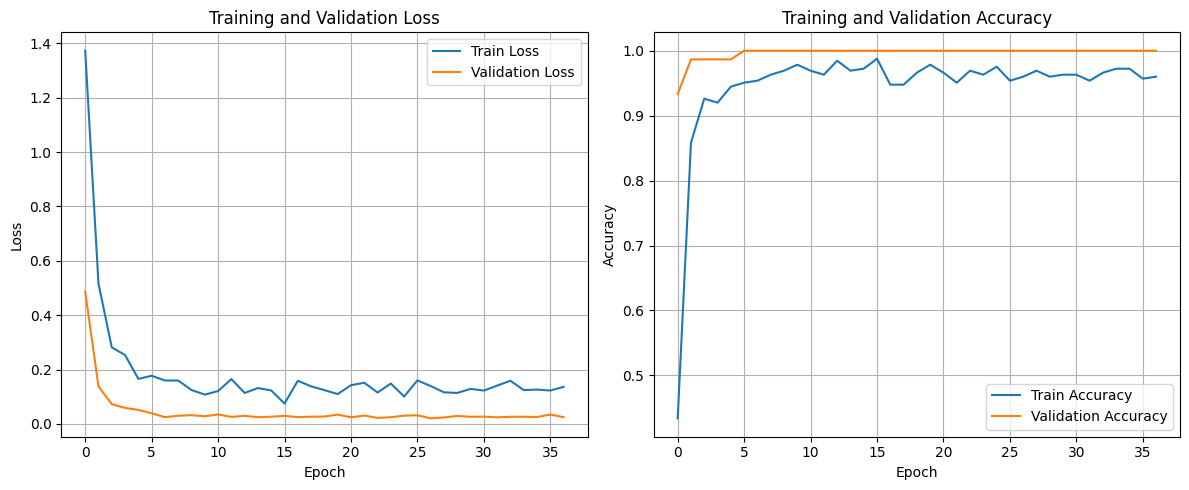

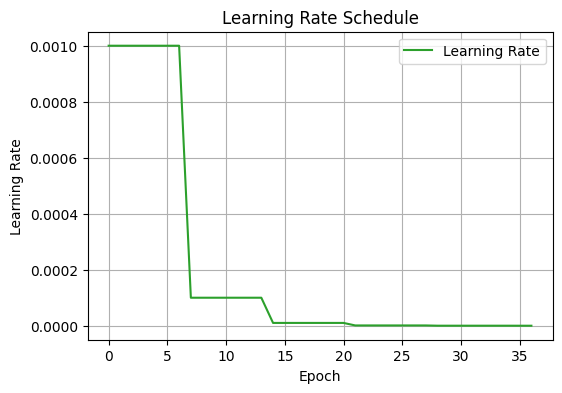

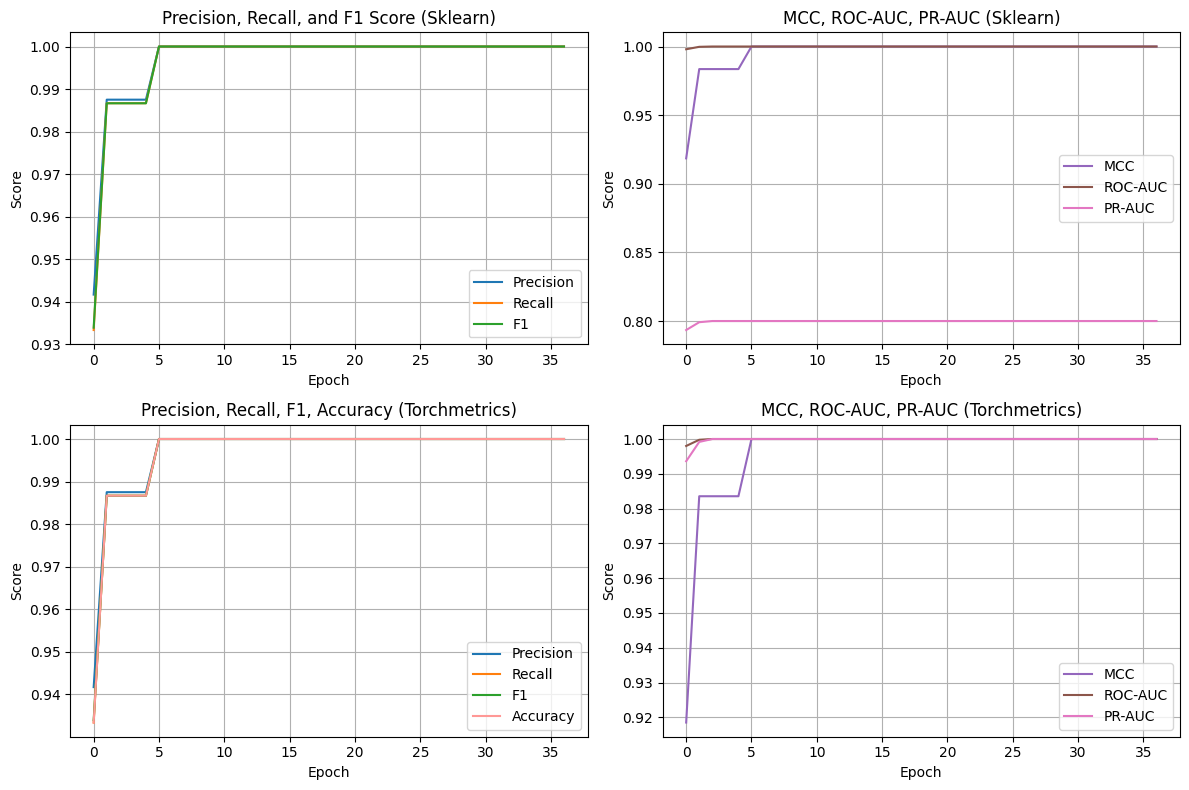


--- Визуализация для batch_size=16 ---


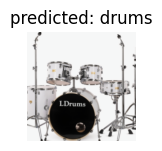

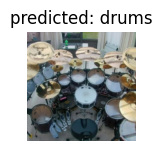

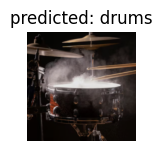

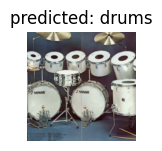

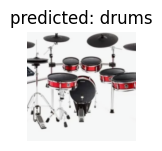

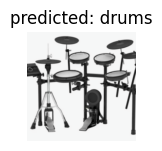


✅ Batch size 16 завершен. Лучшая val acc: 1.0000

Тестирование batch size = 32
Пример батча (batch_size=32):


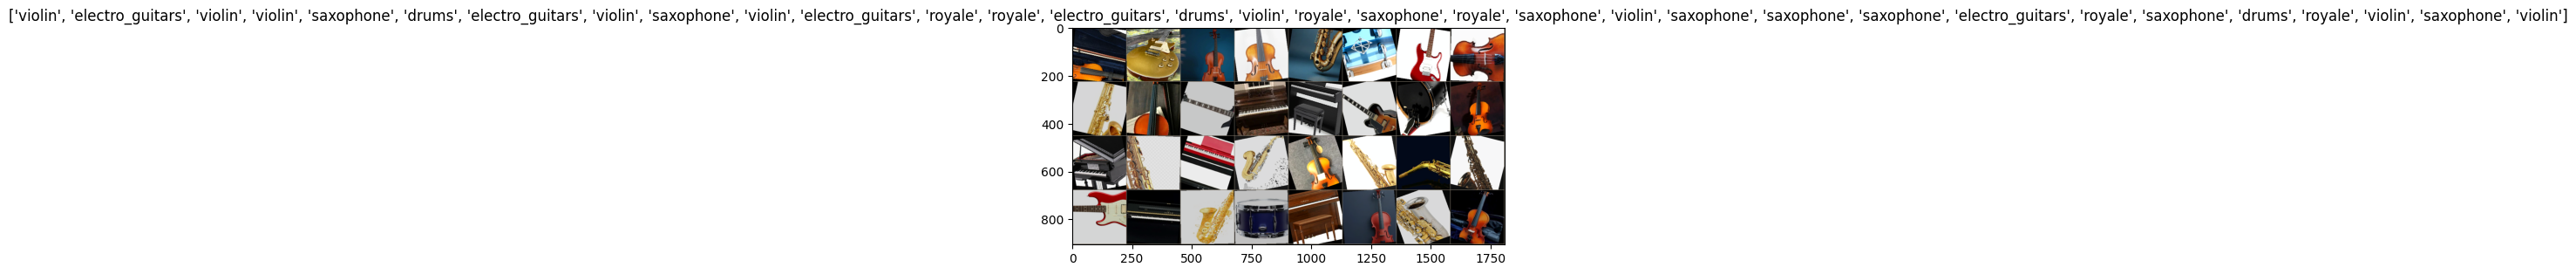

Epoch 0/49
----------
Learning Rate: 0.001000
train Loss: 1.4408 Acc: 0.4062
val Loss: 0.9418 Acc: 0.6400

Epoch 1/49
----------
Learning Rate: 0.001000
train Loss: 0.8675 Acc: 0.7323
val Loss: 0.2947 Acc: 0.9733

Epoch 2/49
----------
Learning Rate: 0.001000
train Loss: 0.5133 Acc: 0.8892
val Loss: 0.1278 Acc: 1.0000

Epoch 3/49
----------
Learning Rate: 0.001000
train Loss: 0.3209 Acc: 0.9231
val Loss: 0.0845 Acc: 1.0000

Epoch 4/49
----------
Learning Rate: 0.001000
train Loss: 0.2317 Acc: 0.9600
val Loss: 0.0763 Acc: 1.0000

Epoch 5/49
----------
Learning Rate: 0.001000
train Loss: 0.1593 Acc: 0.9723
val Loss: 0.0569 Acc: 1.0000

Epoch 6/49
----------
Learning Rate: 0.001000
train Loss: 0.1738 Acc: 0.9662
val Loss: 0.0520 Acc: 1.0000

Epoch 7/49
----------
Learning Rate: 0.000100
train Loss: 0.1746 Acc: 0.9477
val Loss: 0.0484 Acc: 1.0000

Epoch 8/49
----------
Learning Rate: 0.000100
train Loss: 0.1962 Acc: 0.9600
val Loss: 0.0426 Acc: 1.0000

Epoch 9/49
----------
Learning Rate: 

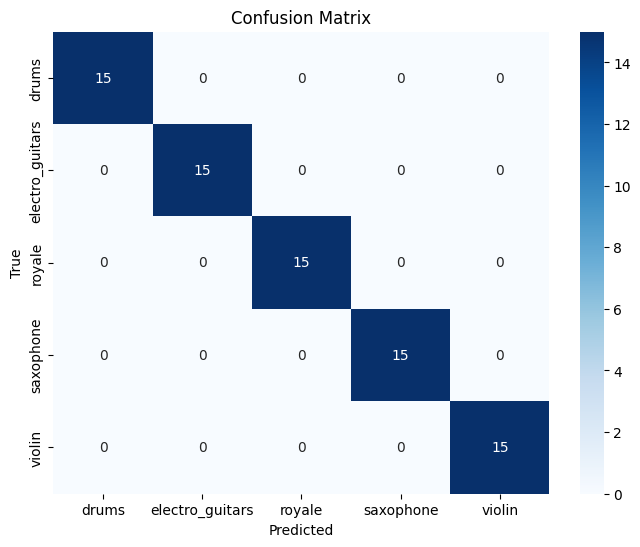

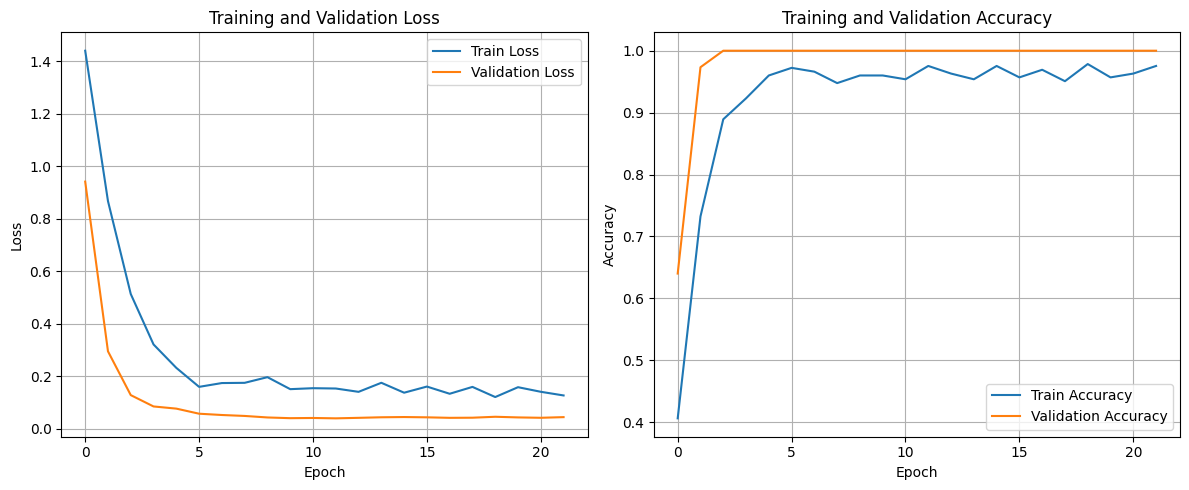

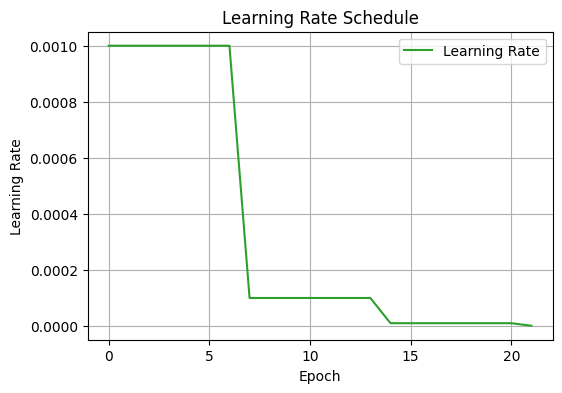

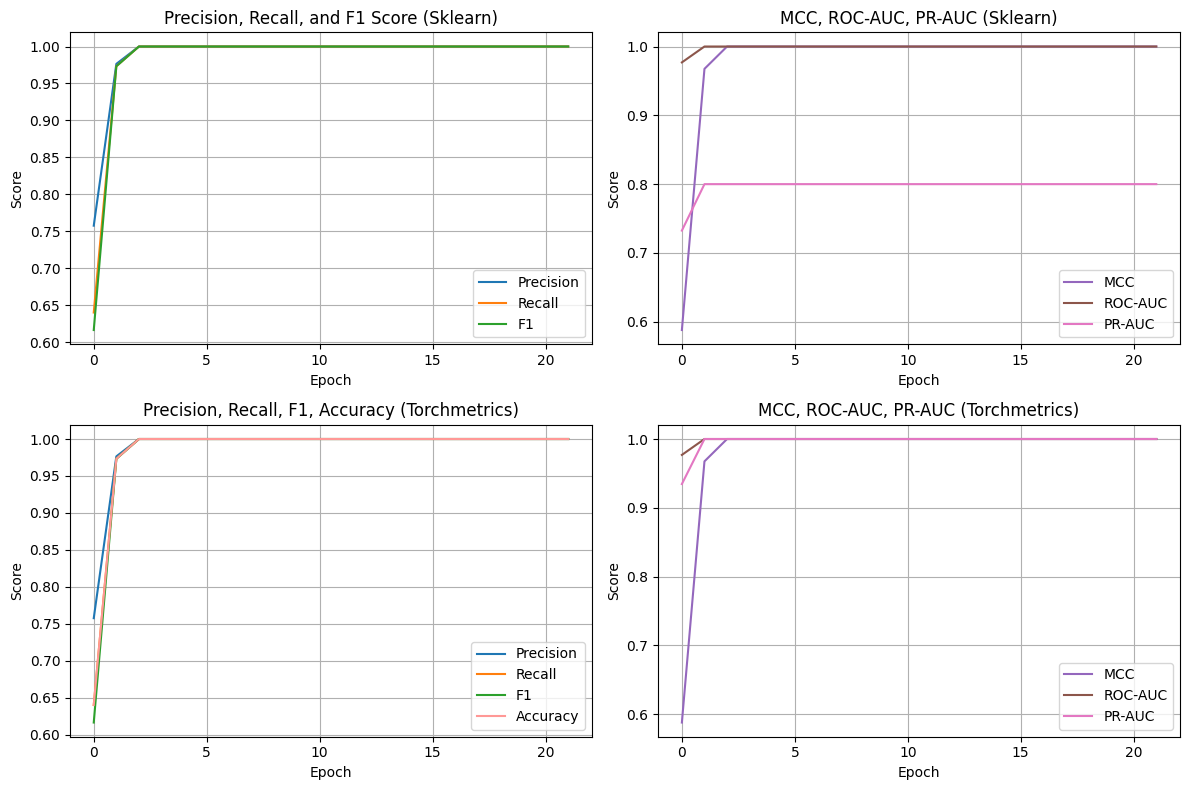


--- Визуализация для batch_size=32 ---


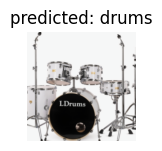

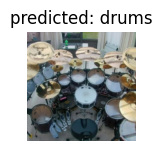

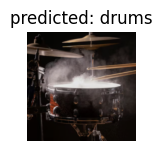

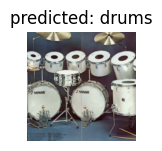

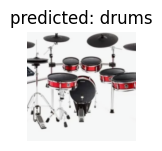

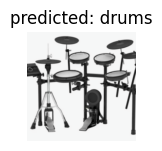


✅ Batch size 32 завершен. Лучшая val acc: 1.0000


In [31]:
batch_sizes = [4, 8, 16, 32]
results_bs = {}

for bs in batch_sizes:
    print(f"\n{'='*50}")
    print(f"Тестирование batch size = {bs}")
    print('='*50)
    # Создаем даталоадеры с новым batch_size
    dataloaders_bs = {
        x: torch.utils.data.DataLoader(
            image_datasets[x], 
            batch_size=bs,
            shuffle=True if x == 'train' else False, 
            num_workers=4
        )
        for x in ['train', 'val']
    }

    inputs: torch.Tensor
    classes: torch.Tensor
    inputs, classes = next(iter(dataloaders_bs['train']))
    out: torch.Tensor = torchvision.utils.make_grid(inputs)
    print(f"Пример батча (batch_size={bs}):")
    imshow(out, title=[class_names[x] for x in classes])
    plt.show()

    model = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    model, metrics, lrs, val_metrics = train_model_with_dataloaders(
        model_arch=model,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        dataloaders=dataloaders_bs,
        dataset_sizes={x: len(image_datasets[x]) for x in ['train', 'val']},
        num_epochs=50,
        patience=10
    )

    # Plot training metrics
    plot_training_metrics_new(
        metrics, 
        lrs, 
        val_metrics, 
        plot_roc_pr=True
    )

    results_bs[bs] = {
        'model': model,
        'metrics': metrics,
        'val_metrics': val_metrics,
        'final_val_acc': metrics['val_acc'][-1] if metrics['val_acc'] else 0,
        'best_val_acc': max(metrics['val_acc']) if metrics['val_acc'] else 0
    }
    
    # Визуализация для текущего batch size
    print(f"\n--- Визуализация для batch_size={bs} ---")
    visualize_model_optimized(model, dataloaders_bs)
    
    print(f"\n✅ Batch size {bs} завершен. Лучшая val acc: {results_bs[bs]['best_val_acc']:.4f}")

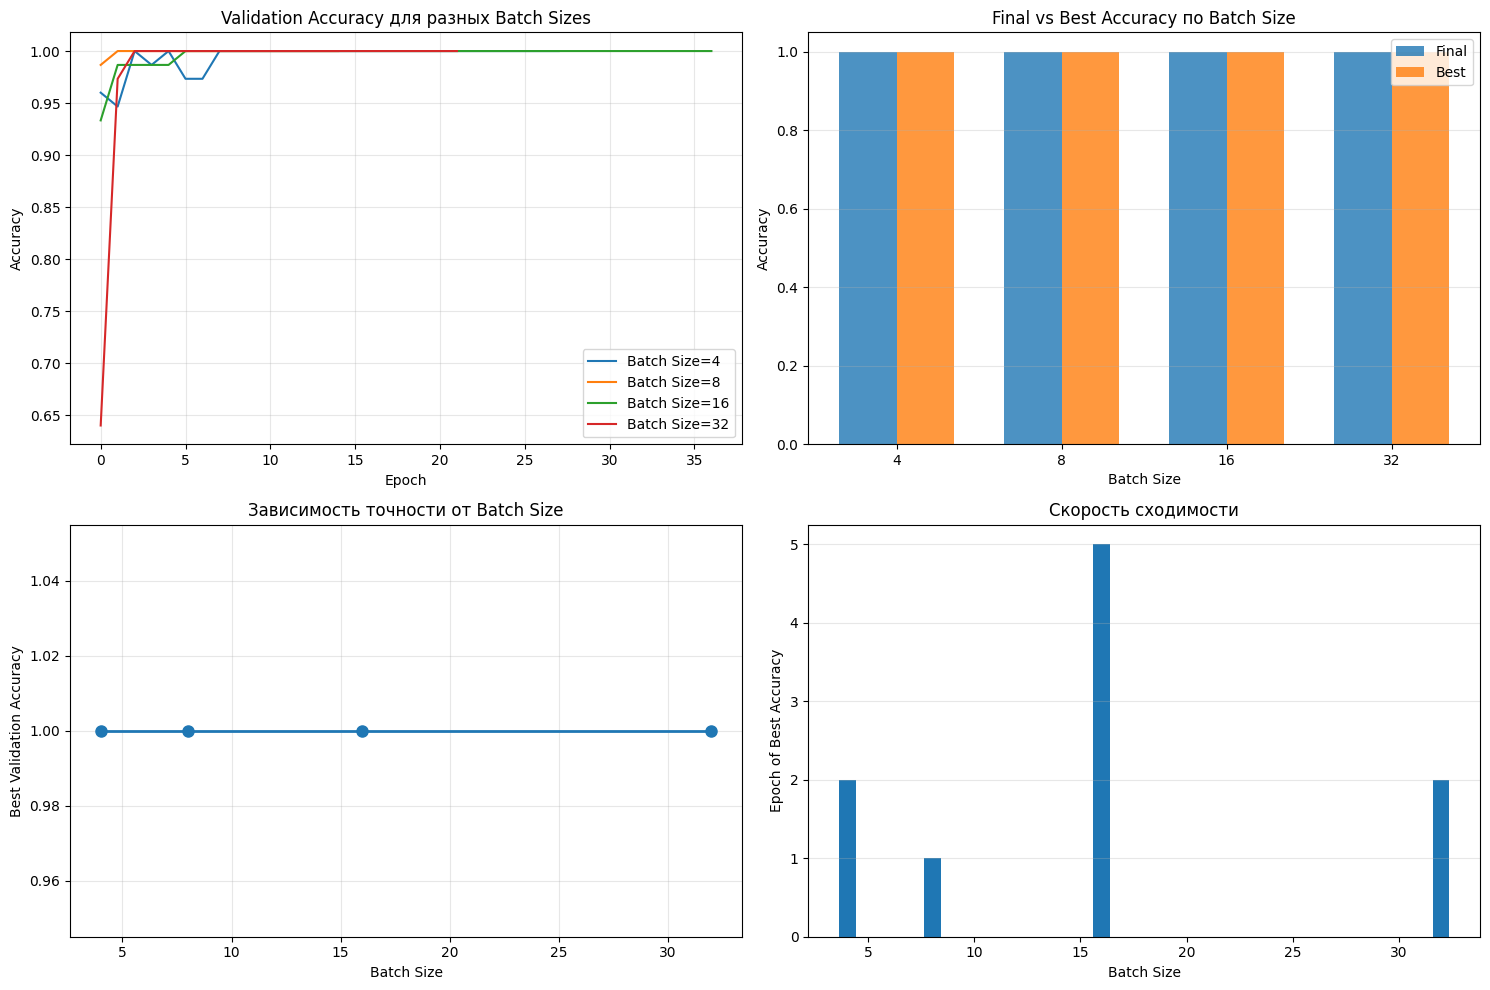


СРАВНЕНИЕ BATCH SIZES
Batch Size   Final Acc    Best Acc     Best Epoch  
------------------------------------------------
4            1.0000       1.0000       2           
8            1.0000       1.0000       1           
16           1.0000       1.0000       5           
32           1.0000       1.0000       2           


In [ ]:
def plot_batch_size_comparison(results_bs):
    """
    Сравнение разных batch sizes
    """
    plt.figure(figsize=(15, 10))
    
    batch_sizes = sorted(results_bs.keys())
    
    # График 1: Сравнение кривых обучения
    plt.subplot(2, 2, 1)
    for bs in batch_sizes:
        plt.plot(results_bs[bs]['metrics']['val_acc'], 
                label=f'Batch Size={bs}', linewidth=1.5)
    plt.title('Validation Accuracy для разных Batch Sizes')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 2: Финальные значения
    plt.subplot(2, 2, 2)
    final_acc = [results_bs[bs]['final_val_acc'] for bs in batch_sizes]
    best_acc = [results_bs[bs]['best_val_acc'] for bs in batch_sizes]
    
    x = range(len(batch_sizes))
    width = 0.35
    plt.bar([i - width/2 for i in x], final_acc, width, label='Final', alpha=0.8)
    plt.bar([i + width/2 for i in x], best_acc, width, label='Best', alpha=0.8)
    plt.xlabel('Batch Size')
    plt.ylabel('Accuracy')
    plt.title('Final vs Best Accuracy по Batch Size')
    plt.xticks(x, batch_sizes)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    # График 3: Время обучения
    plt.subplot(2, 2, 3)
    # Здесь нужно добавить измерение времени в train_model
    # Пока просто покажем зависимость
    plt.plot(batch_sizes, best_acc, 'o-', linewidth=2, markersize=8)
    plt.xlabel('Batch Size')
    plt.ylabel('Best Validation Accuracy')
    plt.title('Зависимость точности от Batch Size')
    plt.grid(True, alpha=0.3)
    
    # График 4: Скорость сходимости (эпоха достижения лучшего результата)
    plt.subplot(2, 2, 4)
    best_epochs = []
    for bs in batch_sizes:
        val_acc = results_bs[bs]['metrics']['val_acc']
        best_epoch = np.argmax(val_acc) if val_acc else 0
        best_epochs.append(best_epoch)
    
    plt.bar(batch_sizes, best_epochs)
    plt.xlabel('Batch Size')
    plt.ylabel('Epoch of Best Accuracy')
    plt.title('Скорость сходимости')
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Таблица результатов
    print("\n" + "="*60)
    print("СРАВНЕНИЕ BATCH SIZES")
    print("="*60)
    print(f"{'Batch Size':<12} {'Final Acc':<12} {'Best Acc':<12} {'Best Epoch':<12}")
    print("-"*48)
    for bs in batch_sizes:
        val_acc = results_bs[bs]['metrics']['val_acc']
        best_epoch = np.argmax(val_acc) if val_acc else 0
        print(f"{bs:<12} {results_bs[bs]['final_val_acc']:<12.4f} "
              f"{results_bs[bs]['best_val_acc']:<12.4f} {best_epoch:<12}")

plot_batch_size_comparison(results_bs)

### Исследование 3: Способ обучения

In [33]:
# 1. Finetuning (все слои обучаются)
model_ft_1 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft_1.fc.in_features
model_ft_1.fc = nn.Linear(num_ftrs, num_classes)
model_ft_1 = model_ft_1.to(device)
optimizer_ft = optim.SGD(model_ft_1.parameters(), lr=0.001, momentum=0.9)

# 2. Feature Extractor (только последний слой)
model_fe_1 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_fe_1.parameters():
    param.requires_grad = False
num_ftrs = model_fe_1.fc.in_features
model_fe_1.fc = nn.Linear(num_ftrs, num_classes)
model_fe_1 = model_fe_1.to(device)
optimizer_fe = optim.SGD(model_fe_1.fc.parameters(), lr=0.001, momentum=0.9)

Epoch 0/199
----------
Learning Rate: 0.001000
train Loss: 0.9791 Acc: 0.6062
val Loss: 0.0745 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.4603 Acc: 0.8308
val Loss: 0.0297 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 0.6747 Acc: 0.7692
val Loss: 0.1012 Acc: 0.9733
val Precision_skl: 0.9765, Recall_skl: 0.9733, F1_skl: 0.9732
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9733, Recall

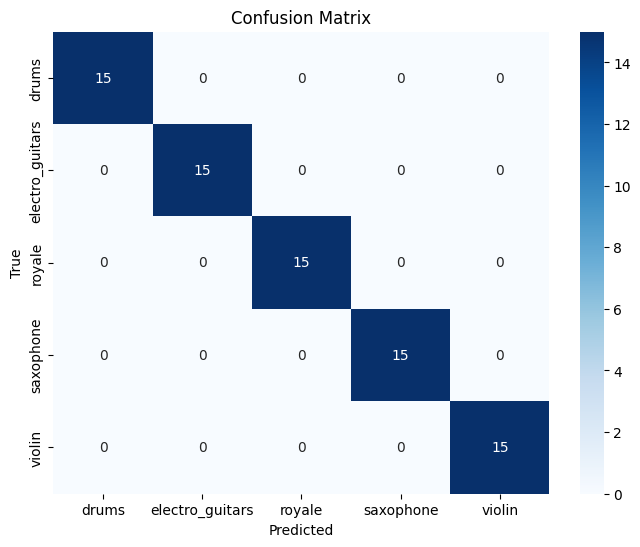

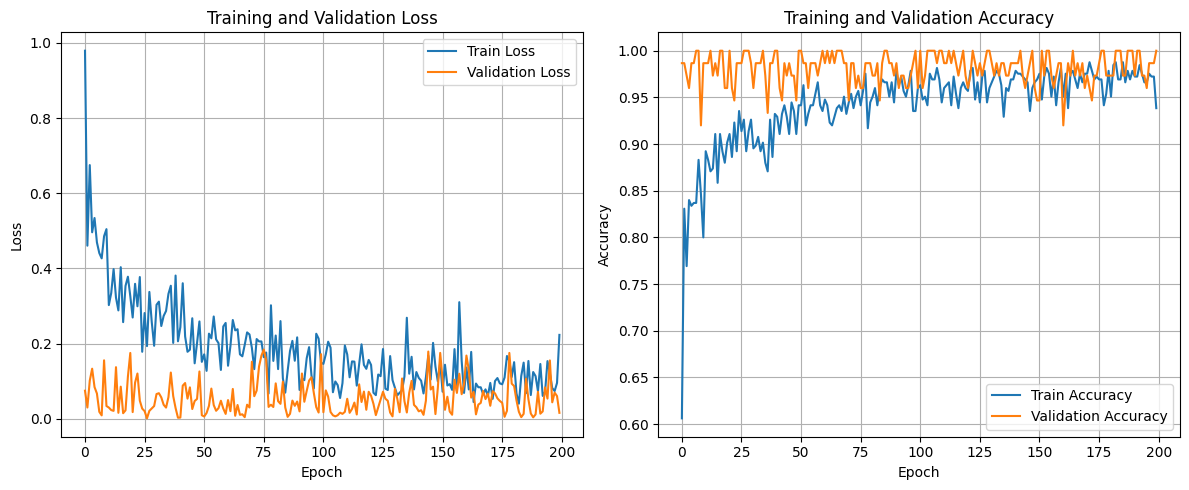

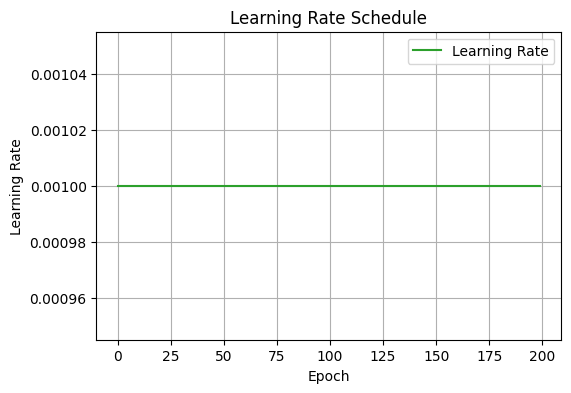

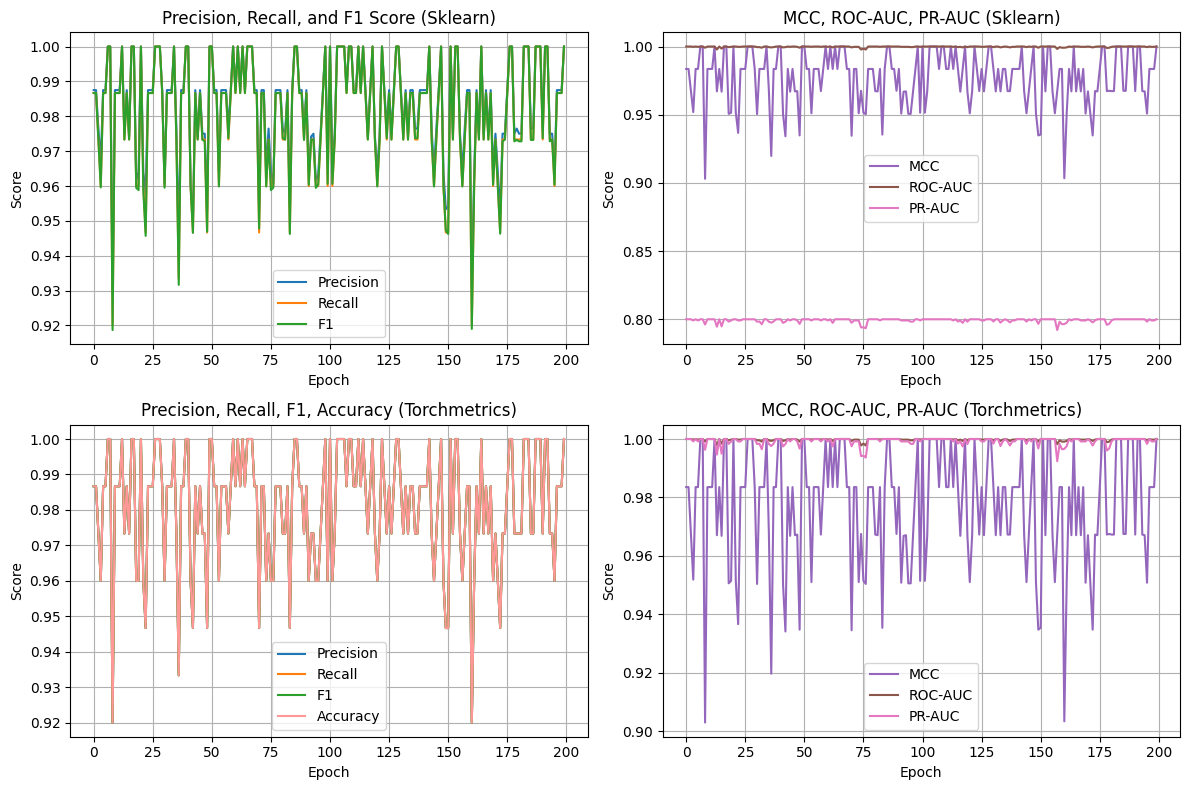

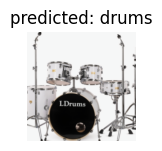

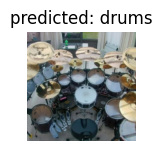

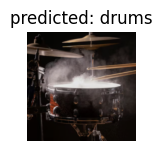

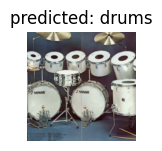

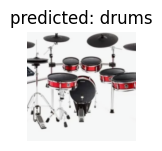

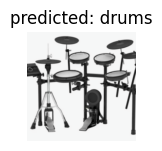


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 0.9901
Test Precision (macro): 0.9905
Test Recall (macro): 0.9905
Test F1 (macro): 0.9902
Test MCC: 0.9877


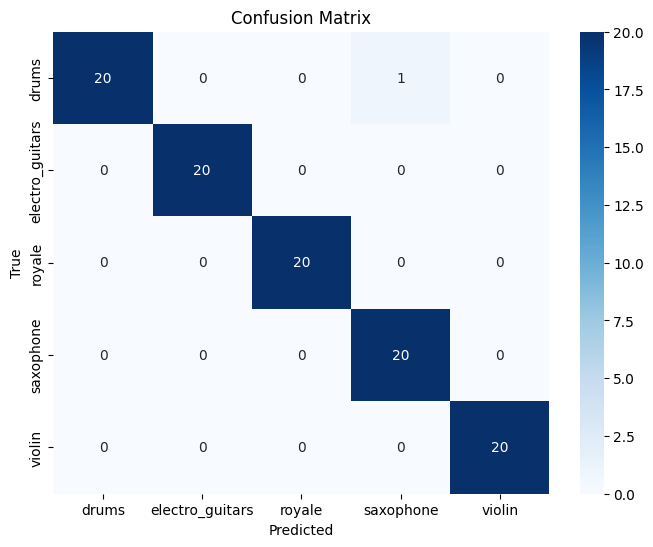

In [34]:
model_ft_1, metrics_1, learning_rates_1, val_metrics_1 = train_model_new(
    model_ft_1, 
    criterion, 
    optimizer_ft, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics_new(
    metrics_1, 
    learning_rates_1, 
    val_metrics_1, 
    plot_roc_pr=True
)

visualize_model(model_ft_1)

best_model: Any = model_ft_1  # или model_conv - лучшая модель после экспериментов
test_results = evaluate_on_test(
    model_ft_1, 
    dataloaders['test'], 
    class_names, 
    device
)

Epoch 0/199
----------
Learning Rate: 0.001000
train Loss: 1.3030 Acc: 0.4677
val Loss: 0.1544 Acc: 1.0000
val Precision_skl: 1.0000, Recall_skl: 1.0000, F1_skl: 1.0000
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 1.0000, Recall_torch: 1.0000, F1_torch: 1.0000
val Accuracy_torch: 1.0000, MCC_torch: 1.0000
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 1/199
----------
Learning Rate: 0.001000
train Loss: 0.7673 Acc: 0.7323
val Loss: 0.0822 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall_torch: 0.9867, F1_torch: 0.9867
val Accuracy_torch: 0.9867, MCC_torch: 0.9836
val ROC-AUC_torch: 1.0000, PR-AUC_torch: 1.0000

Epoch 2/199
----------
Learning Rate: 0.001000
train Loss: 0.5876 Acc: 0.8062
val Loss: 0.0613 Acc: 0.9867
val Precision_skl: 0.9875, Recall_skl: 0.9867, F1_skl: 0.9867
val ROC-AUC_skl: 1.0000, PR-AUC_skl: 0.8000
val Precision_torch: 0.9867, Recall

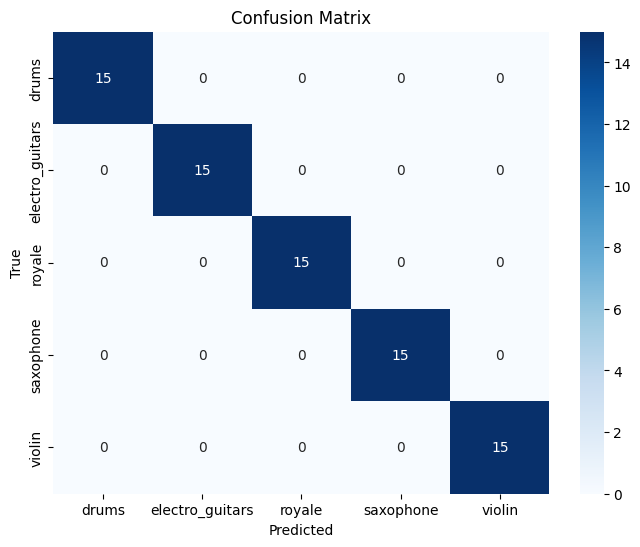

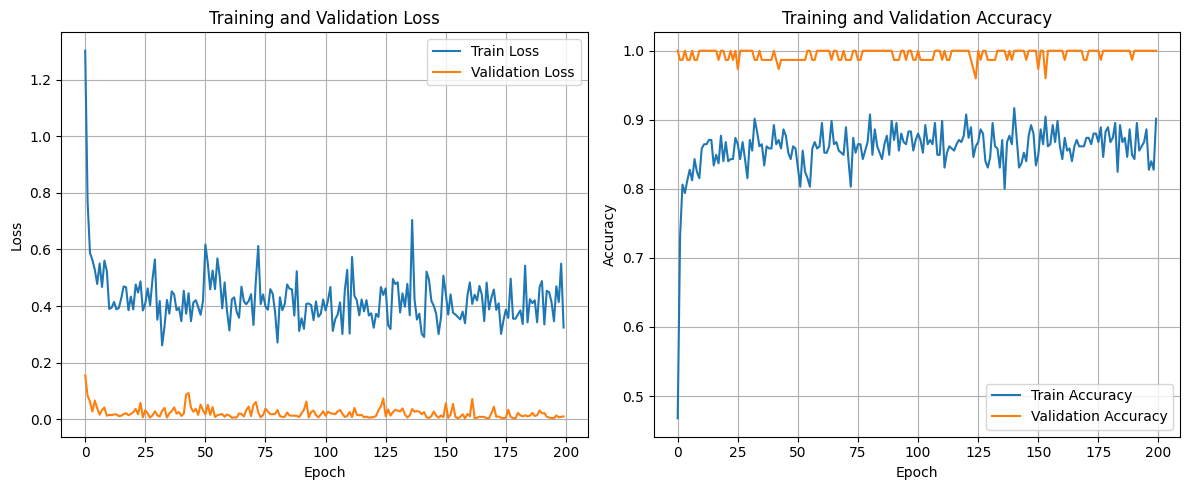

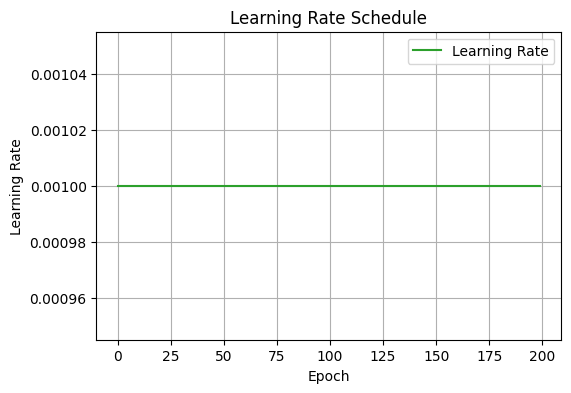

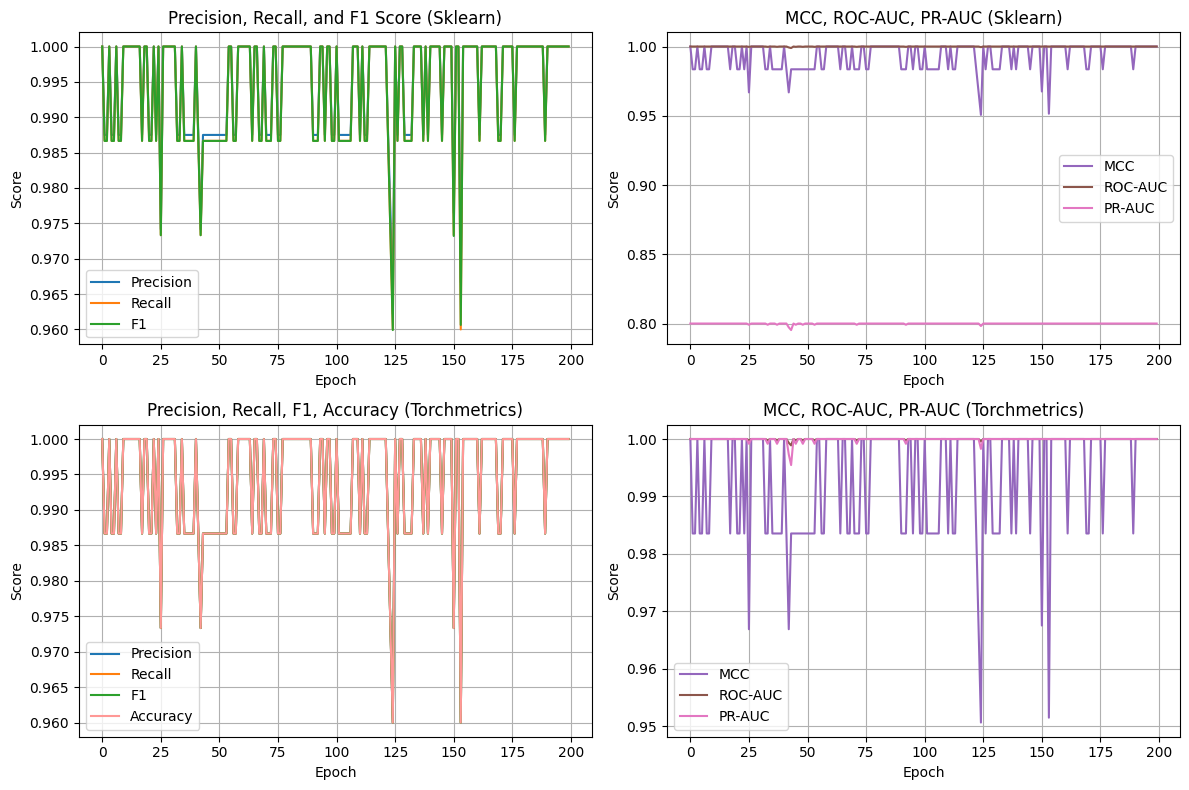

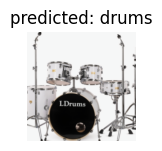

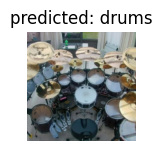

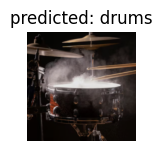

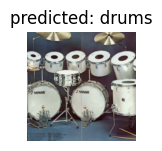

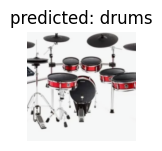

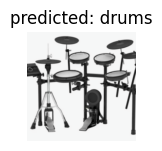


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


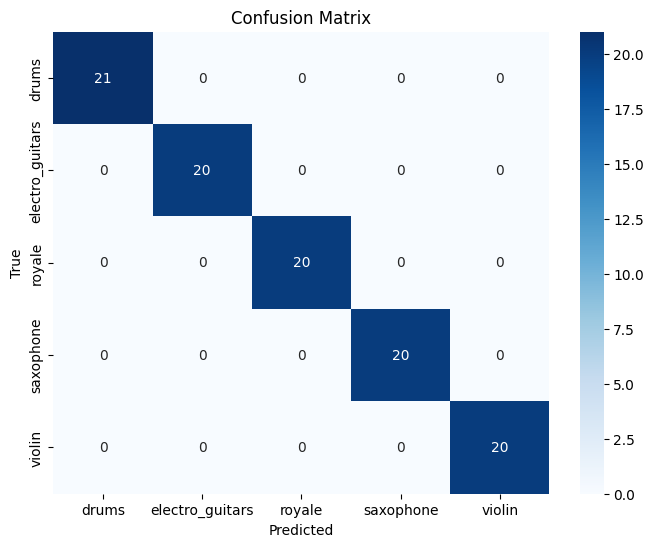

In [35]:
model_fe_1, metrics_2, learning_rates_2, val_metrics_2 = train_model_new(
    model_fe_1, 
    criterion, 
    optimizer_fe, 
    exp_lr_scheduler, 
    num_epochs=200, 
    patience=200
)

# Plot training metrics
plot_training_metrics_new(
    metrics_2, 
    learning_rates_2, 
    val_metrics_2, 
    plot_roc_pr=True
)

visualize_model(model_ft_1)

best_model: Any = model_fe_1
test_results = evaluate_on_test(
    model_fe_1, 
    dataloaders['test'], 
    class_names, 
    device
)

### Исследование 4: Размер обучающей выборки


Тестирование размера обучающей выборки = 20.0%
Размер полного train датасета: 325
Размер подвыборки (20.0%): 65
Epoch 0/99
----------
Learning Rate: 0.001000
train Loss: 1.6357 Acc: 0.3231
val Loss: 1.4936 Acc: 0.2133

Epoch 1/99
----------
Learning Rate: 0.001000
train Loss: 1.5635 Acc: 0.3231
val Loss: 1.2295 Acc: 0.3733

Epoch 2/99
----------
Learning Rate: 0.001000
train Loss: 1.2305 Acc: 0.5231
val Loss: 0.8170 Acc: 0.8933

Epoch 3/99
----------
Learning Rate: 0.001000
train Loss: 0.9649 Acc: 0.7231
val Loss: 0.6078 Acc: 0.8400

Epoch 4/99
----------
Learning Rate: 0.001000
train Loss: 0.8197 Acc: 0.7538
val Loss: 0.5180 Acc: 0.8533

Epoch 5/99
----------
Learning Rate: 0.001000
train Loss: 0.6923 Acc: 0.8000
val Loss: 0.4288 Acc: 0.8667

Epoch 6/99
----------
Learning Rate: 0.001000
train Loss: 0.4471 Acc: 0.8923
val Loss: 0.2385 Acc: 0.9733

Epoch 7/99
----------
Learning Rate: 0.000100
train Loss: 0.4440 Acc: 0.8769
val Loss: 0.2218 Acc: 0.9733

Epoch 8/99
----------
Learning 

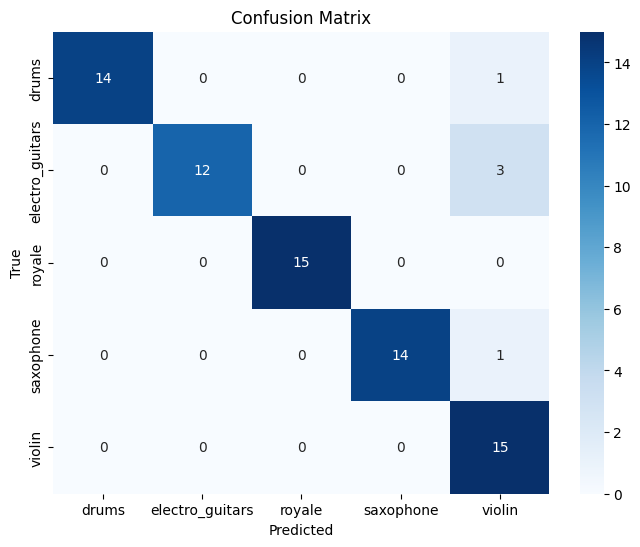


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 0.9901
Test Precision (macro): 0.9905
Test Recall (macro): 0.9900
Test F1 (macro): 0.9900
Test MCC: 0.9877


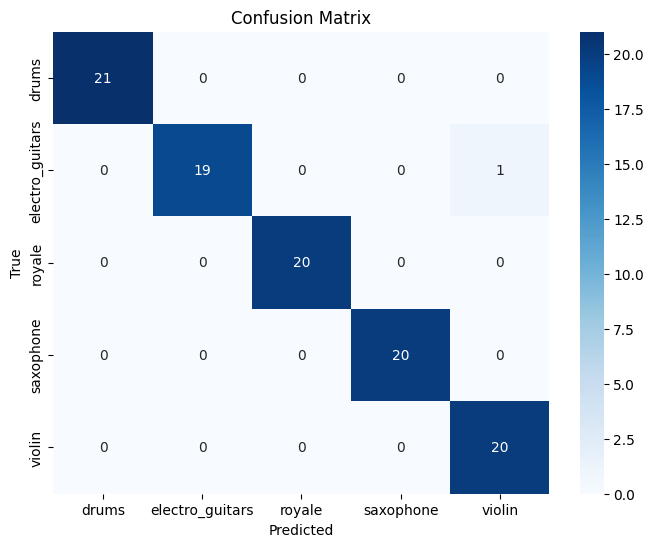


✅ Размер 20.0% завершен. Лучшая val acc: 0.9867
   Test accuracy: 0.9901

Тестирование размера обучающей выборки = 40.0%
Размер полного train датасета: 325
Размер подвыборки (40.0%): 130
Epoch 0/99
----------
Learning Rate: 0.001000
train Loss: 1.7702 Acc: 0.1923
val Loss: 1.3041 Acc: 0.5067

Epoch 1/99
----------
Learning Rate: 0.001000
train Loss: 1.1669 Acc: 0.6077
val Loss: 0.5777 Acc: 0.9467

Epoch 2/99
----------
Learning Rate: 0.001000
train Loss: 0.6871 Acc: 0.8692
val Loss: 0.2971 Acc: 0.9867

Epoch 3/99
----------
Learning Rate: 0.001000
train Loss: 0.5135 Acc: 0.8846
val Loss: 0.1810 Acc: 1.0000

Epoch 4/99
----------
Learning Rate: 0.001000
train Loss: 0.3811 Acc: 0.8769
val Loss: 0.1323 Acc: 0.9867

Epoch 5/99
----------
Learning Rate: 0.001000
train Loss: 0.3232 Acc: 0.9154
val Loss: 0.0710 Acc: 1.0000

Epoch 6/99
----------
Learning Rate: 0.001000
train Loss: 0.2908 Acc: 0.9231
val Loss: 0.0791 Acc: 0.9733

Epoch 7/99
----------
Learning Rate: 0.000100
train Loss: 0.270

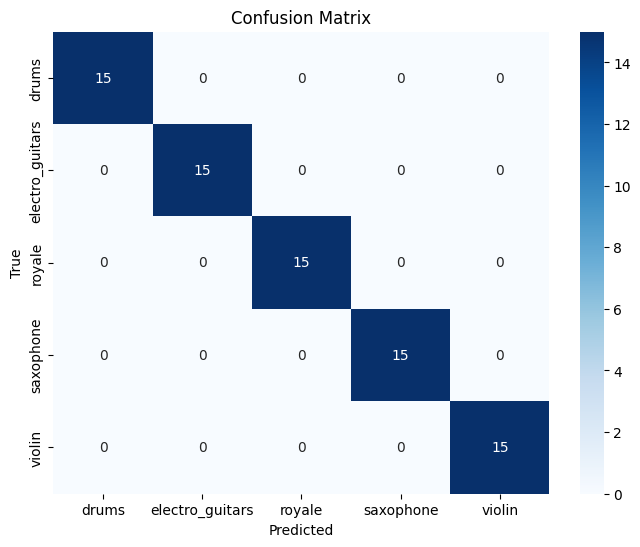


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


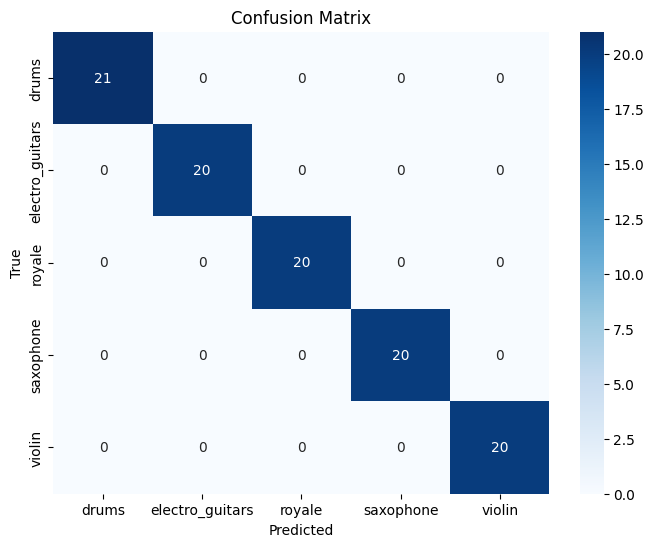


✅ Размер 40.0% завершен. Лучшая val acc: 1.0000
   Test accuracy: 1.0000

Тестирование размера обучающей выборки = 60.0%
Размер полного train датасета: 325
Размер подвыборки (60.0%): 195
Epoch 0/99
----------
Learning Rate: 0.001000
train Loss: 1.5068 Acc: 0.3641
val Loss: 0.8301 Acc: 0.7333

Epoch 1/99
----------
Learning Rate: 0.001000
train Loss: 0.8056 Acc: 0.8103
val Loss: 0.2548 Acc: 1.0000

Epoch 2/99
----------
Learning Rate: 0.001000
train Loss: 0.5229 Acc: 0.8615
val Loss: 0.1047 Acc: 1.0000

Epoch 3/99
----------
Learning Rate: 0.001000
train Loss: 0.3607 Acc: 0.8923
val Loss: 0.0671 Acc: 1.0000

Epoch 4/99
----------
Learning Rate: 0.001000
train Loss: 0.2976 Acc: 0.9128
val Loss: 0.0601 Acc: 1.0000

Epoch 5/99
----------
Learning Rate: 0.001000
train Loss: 0.2347 Acc: 0.9385
val Loss: 0.0580 Acc: 0.9867

Epoch 6/99
----------
Learning Rate: 0.001000
train Loss: 0.1867 Acc: 0.9590
val Loss: 0.0323 Acc: 1.0000

Epoch 7/99
----------
Learning Rate: 0.000100
train Loss: 0.175

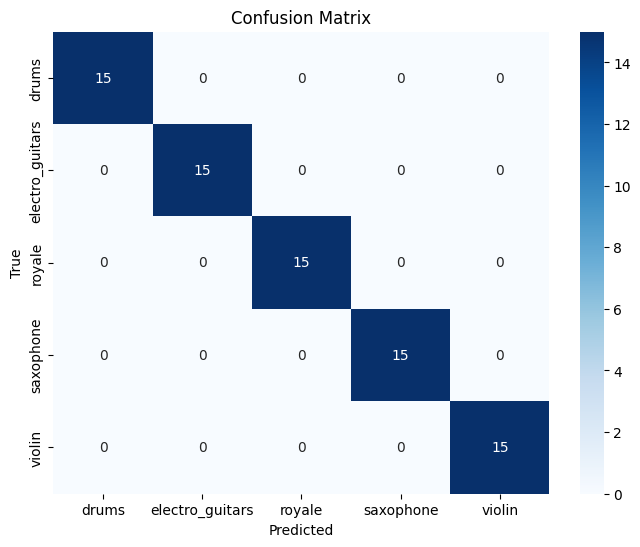


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


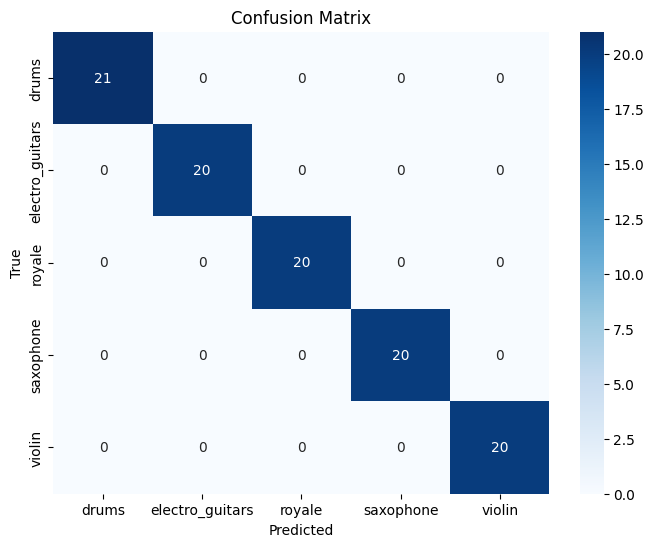


✅ Размер 60.0% завершен. Лучшая val acc: 1.0000
   Test accuracy: 1.0000

Тестирование размера обучающей выборки = 80.0%
Размер полного train датасета: 325
Размер подвыборки (80.0%): 260
Epoch 0/99
----------
Learning Rate: 0.001000
train Loss: 1.3186 Acc: 0.5192
val Loss: 0.5163 Acc: 0.9600

Epoch 1/99
----------
Learning Rate: 0.001000
train Loss: 0.6197 Acc: 0.8577
val Loss: 0.1692 Acc: 1.0000

Epoch 2/99
----------
Learning Rate: 0.001000
train Loss: 0.3254 Acc: 0.8923
val Loss: 0.0718 Acc: 1.0000

Epoch 3/99
----------
Learning Rate: 0.001000
train Loss: 0.2581 Acc: 0.9308
val Loss: 0.0560 Acc: 1.0000

Epoch 4/99
----------
Learning Rate: 0.001000
train Loss: 0.2239 Acc: 0.9269
val Loss: 0.0448 Acc: 1.0000

Epoch 5/99
----------
Learning Rate: 0.001000
train Loss: 0.2084 Acc: 0.9615
val Loss: 0.0424 Acc: 0.9867

Epoch 6/99
----------
Learning Rate: 0.001000
train Loss: 0.1515 Acc: 0.9615
val Loss: 0.0349 Acc: 1.0000

Epoch 7/99
----------
Learning Rate: 0.000100
train Loss: 0.148

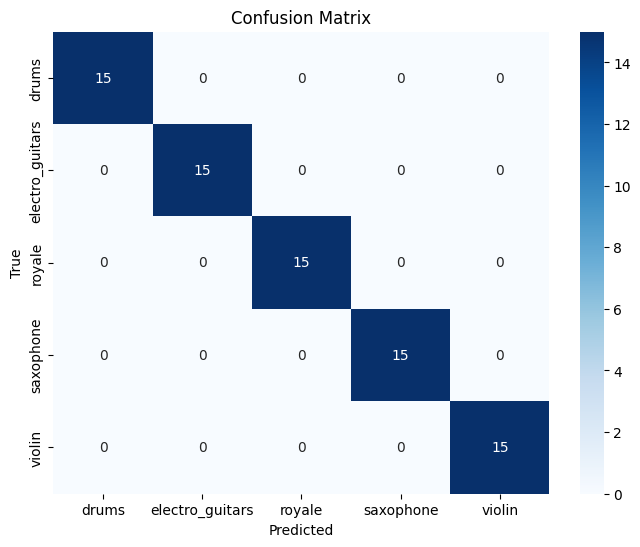


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


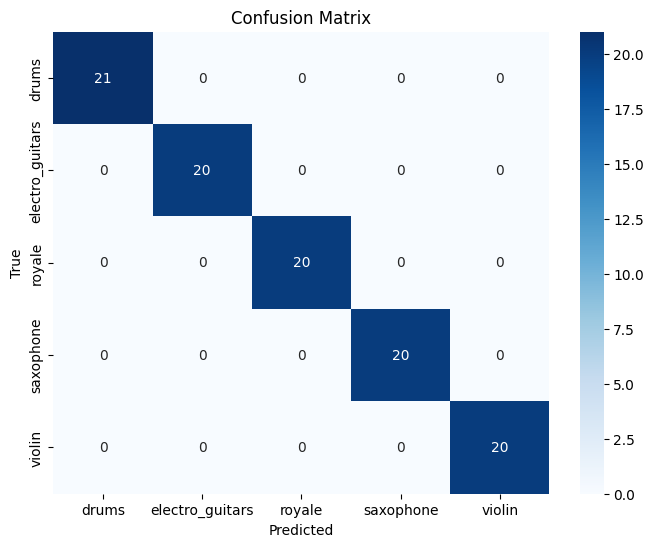


✅ Размер 80.0% завершен. Лучшая val acc: 1.0000
   Test accuracy: 1.0000

Тестирование размера обучающей выборки = 100.0%
Размер полного train датасета: 325
Размер подвыборки (100.0%): 325
Epoch 0/99
----------
Learning Rate: 0.001000
train Loss: 1.3192 Acc: 0.4985
val Loss: 0.4419 Acc: 0.9333

Epoch 1/99
----------
Learning Rate: 0.001000
train Loss: 0.5243 Acc: 0.8831
val Loss: 0.1036 Acc: 0.9867

Epoch 2/99
----------
Learning Rate: 0.001000
train Loss: 0.2883 Acc: 0.9262
val Loss: 0.0541 Acc: 1.0000

Epoch 3/99
----------
Learning Rate: 0.001000
train Loss: 0.3039 Acc: 0.9169
val Loss: 0.0457 Acc: 1.0000

Epoch 4/99
----------
Learning Rate: 0.001000
train Loss: 0.1635 Acc: 0.9631
val Loss: 0.0305 Acc: 1.0000

Epoch 5/99
----------
Learning Rate: 0.001000
train Loss: 0.1508 Acc: 0.9600
val Loss: 0.0258 Acc: 1.0000

Epoch 6/99
----------
Learning Rate: 0.001000
train Loss: 0.1661 Acc: 0.9508
val Loss: 0.0245 Acc: 1.0000

Epoch 7/99
----------
Learning Rate: 0.000100
train Loss: 0.1

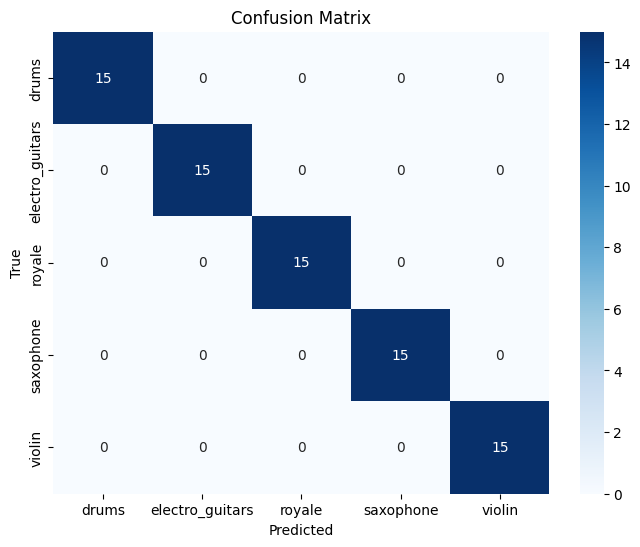


ФИНАЛЬНАЯ ОЦЕНКА НА TEST ДАТАСЕТЕ
Test Accuracy: 1.0000
Test Precision (macro): 1.0000
Test Recall (macro): 1.0000
Test F1 (macro): 1.0000
Test MCC: 1.0000


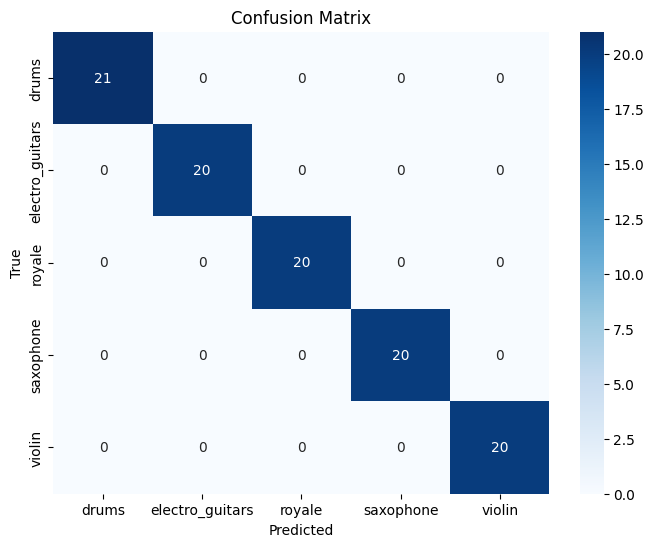


✅ Размер 100.0% завершен. Лучшая val acc: 1.0000
   Test accuracy: 1.0000


In [37]:
# Исследование 3: Влияние размера обучающей выборки
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
results_size = {}

# Полный validation set для оценки
val_loader_full = dataloaders['val']
test_loader_full = dataloaders['test']

for size in train_sizes:
    print(f"\n{'='*50}")
    print(f"Тестирование размера обучающей выборки = {size*100}%")
    print('='*50)
    
    # Очищаем кэш
    torch.cuda.empty_cache()
    
    # Создаем подвыборку из train датасета
    train_dataset = image_datasets['train']
    train_size = int(len(train_dataset) * size)
    
    # Используем random_split для создания подвыборки
    subset_train, _ = torch.utils.data.random_split(
        train_dataset, 
        [train_size, len(train_dataset) - train_size],
        generator=torch.Generator().manual_seed(42)  # для воспроизводимости
    )
    
    # Создаем dataloader для подвыборки
    train_loader_subset = torch.utils.data.DataLoader(
        subset_train,
        batch_size=16,  # фиксируем batch size
        shuffle=True,
        num_workers=4
    )
    
    print(f"Размер полного train датасета: {len(train_dataset)}")
    print(f"Размер подвыборки ({size*100}%): {len(subset_train)}")
    
    # Создаем новую модель
    model = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    
    # Словарь с dataloaders для обучения
    dataloaders_subset = {
        'train': train_loader_subset,
        'val': dataloaders['val']  # validation остается полным
    }
    
    dataset_sizes_subset = {
        'train': len(subset_train),
        'val': len(image_datasets['val'])
    }
    
    # Обучаем модель
    model, metrics, lrs, val_metrics = train_model_with_dataloaders(
        model_arch=model,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        dataloaders=dataloaders_subset,
        dataset_sizes=dataset_sizes_subset,
        num_epochs=100,
        patience=15
    )
    
    # Оцениваем на test set
    test_accuracy = evaluate_on_test(model, test_loader_full, class_names, device)
    
    # Сохраняем результаты
    results_size[size] = {
        'model': model,
        'metrics': metrics,
        'val_metrics': val_metrics,
        'train_size': len(subset_train),
        'final_val_acc': metrics['val_acc'][-1] if metrics['val_acc'] else 0,
        'best_val_acc': max(metrics['val_acc']) if metrics['val_acc'] else 0,
        'test_accuracy': test_accuracy['accuracy'],
        'train_loss': metrics['train_loss'][-1] if metrics['train_loss'] else 0,
        'val_loss': metrics['val_loss'][-1] if metrics['val_loss'] else 0
    }
    
    print(f"\n✅ Размер {size*100}% завершен. Лучшая val acc: {results_size[size]['best_val_acc']:.4f}")
    print(f"   Test accuracy: {test_accuracy['accuracy']:.4f}")

In [38]:
def plot_train_size_comparison(results_size):
    """
    Сравнение разных размеров обучающей выборки
    """
    plt.figure(figsize=(15, 10))
    
    sizes = sorted(results_size.keys())
    size_percents = [f"{int(s*100)}%" for s in sizes]
    
    # График 1: Кривые обучения для разных размеров
    plt.subplot(2, 2, 1)
    for size in sizes:
        plt.plot(results_size[size]['metrics']['val_acc'], 
                label=f'Train size={int(size*100)}%', linewidth=1.5)
    plt.title('Validation Accuracy для разных размеров выборки')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 2: Зависимость точности от размера выборки
    plt.subplot(2, 2, 2)
    val_acc = [results_size[size]['best_val_acc'] for size in sizes]
    test_acc = [results_size[size]['test_accuracy'] for size in sizes]
    
    x = range(len(sizes))
    width = 0.35
    plt.bar([i - width/2 for i in x], val_acc, width, label='Validation', alpha=0.8)
    plt.bar([i + width/2 for i in x], test_acc, width, label='Test', alpha=0.8)
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel('Accuracy')
    plt.title('Validation vs Test Accuracy')
    plt.xticks(x, size_percents)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    # График 3: Кривая обучения (loss)
    plt.subplot(2, 2, 3)
    for size in sizes:
        plt.plot(results_size[size]['metrics']['train_loss'], 
                '--', label=f'Train {int(size*100)}%', alpha=0.7)
        plt.plot(results_size[size]['metrics']['val_loss'], 
                label=f'Val {int(size*100)}%', linewidth=1.5)
    plt.title('Training и Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # График 4: Разрыв между train и val (переобучение)
    plt.subplot(2, 2, 4)
    overfitting = []
    for size in sizes:
        train_acc = results_size[size]['metrics']['train_acc'][-1]
        val_acc_final = results_size[size]['final_val_acc']
        overfitting.append(train_acc - val_acc_final)
    
    colors = ['green' if o < 0.1 else 'orange' if o < 0.2 else 'red' for o in overfitting]
    plt.bar(size_percents, overfitting, color=colors)
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel('Train - Val Accuracy')
    plt.title('Уровень переобучения')
    plt.axhline(y=0.1, color='green', linestyle='--', alpha=0.5, label='Хорошо (<0.1)')
    plt.axhline(y=0.2, color='orange', linestyle='--', alpha=0.5, label='Средне (<0.2)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [43]:
def analyze_train_size_results(results_size):
    """
    Детальный анализ влияния размера выборки
    """
    print("\n" + "="*60)
    print("АНАЛИЗ ВЛИЯНИЯ РАЗМЕРА ОБУЧАЮЩЕЙ ВЫБОРКИ")
    print("="*60)
    
    sizes = sorted(results_size.keys())
    
    # Таблица результатов
    print(f"\n{'Размер':<12} {'Train samples':<15} {'Val Acc':<12} {'Test Acc':<12} {'Train Loss':<12} {'Val Loss':<12}")
    print("-"*75)
    
    for size in sizes:
        res = results_size[size]
        print(f"{int(size*100):<12} {res['train_size']:<15} "
      f"{res['best_val_acc']:<12.4f} {res['test_accuracy']:<12.4f} "
      f"{res['train_loss']:<12.4f} {res['val_loss']:<12.4f}")
    
    # Анализ зависимости
    print("\n" + "-"*40)
    print("АНАЛИЗ ЗАВИСИМОСТЕЙ:")
    print("-"*40)
    
    test_accs = [results_size[size]['test_accuracy'] for size in sizes]
    train_sizes_num = [results_size[size]['train_size'] for size in sizes]
    
    # Прирост точности
    print("\nПрирост точности при увеличении выборки:")
    for i in range(1, len(sizes)):
        increase = test_accs[i] - test_accs[i-1]
        size_increase = train_sizes_num[i] - train_sizes_num[i-1]
        print(f"  {int(sizes[i-1]*100)}% -> {int(sizes[i]*100)}%: +{increase:.4f} "
              f"(+{size_increase} samples)")
    
    # Закон убывающей отдачи
    print("\nЭффективность добавленных данных:")
    for i in range(1, len(sizes)):
        efficiency = (test_accs[i] - test_accs[i-1]) / (train_sizes_num[i] - train_sizes_num[i-1])
        print(f"  {int(sizes[i-1]*100)}% -> {int(sizes[i]*100)}%: {efficiency:.6f} точности на образец")
    
    # Оптимальный размер
    best_size_idx = np.argmax(test_accs)
    print(f"\n🏆 Оптимальный размер выборки: {int(sizes[best_size_idx]*100)}% "
          f"({train_sizes_num[best_size_idx]} изображений)")
    print(f"   Достигнутая точность на test: {test_accs[best_size_idx]:.4f}")
    
    # Минимально достаточный размер (95% от максимума)
    max_acc = max(test_accs)
    threshold = 0.95 * max_acc
    for i, acc in enumerate(test_accs):
        if acc >= threshold:
            print(f"\n📊 Минимально достаточный размер: {int(sizes[i]*100)}% "
                  f"({train_sizes_num[i]} изображений)")
            print(f"   Точность: {acc:.4f} ({(acc/max_acc*100):.1f}% от максимума)")
            break

# Вызываем анализ
analyze_train_size_results(results_size)


АНАЛИЗ ВЛИЯНИЯ РАЗМЕРА ОБУЧАЮЩЕЙ ВЫБОРКИ

Размер       Train samples   Val Acc      Test Acc     Train Loss   Val Loss    
---------------------------------------------------------------------------
20           65              0.9867       0.9901       0.4294       0.2540      
40           130             1.0000       1.0000       0.2192       0.0449      
60           195             1.0000       1.0000       0.1697       0.0343      
80           260             1.0000       1.0000       0.1401       0.0308      
100          325             1.0000       1.0000       0.1477       0.0165      

----------------------------------------
АНАЛИЗ ЗАВИСИМОСТЕЙ:
----------------------------------------

Прирост точности при увеличении выборки:
  20% -> 40%: +0.0099 (+65 samples)
  40% -> 60%: +0.0000 (+65 samples)
  60% -> 80%: +0.0000 (+65 samples)
  80% -> 100%: +0.0000 (+65 samples)

Эффективность добавленных данных:
  20% -> 40%: 0.000152 точности на образец
  40% -> 60%: 0.000000 точ

In [44]:
# Сохраняем результаты эксперимента
import json

# Конвертируем для сохранения
results_to_save = {}
for size, res in results_size.items():
    results_to_save[str(size)] = {
        'train_size': res['train_size'],
        'best_val_acc': float(res['best_val_acc']),
        'test_accuracy': float(res['test_accuracy']),
        'final_val_acc': float(res['final_val_acc']),
        'train_loss': float(res['train_loss']),
        'val_loss': float(res['val_loss'])
    }

with open('train_size_experiment_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=4)

print("\n✅ Результаты сохранены в 'train_size_experiment_results.json'")


✅ Результаты сохранены в 'train_size_experiment_results.json'
